# Assignment 2 — IEOR E4576: Data-Driven Models in Finance
**Fall 2026 — Columbia University**

---


In [1]:
from pathlib import Path
import hashlib
import importlib
import inspect
import importlib.metadata as importlib_metadata
import os
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
import statsmodels.api as sm

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 140,
    'font.size': 9,
    'axes.titlesize': 10,
})

# Freeze the submitted Question 1 data snapshot. These caps apply to the
# student's direct WRDS COT/CL queries only; the instructor-supplied
# futspread package used in Question 2 is intentionally left unmodified.
COT_AS_OF_DATE = pd.Timestamp('2026-09-08')
CL_AS_OF_DATE = pd.Timestamp('2026-04-03')
PYTHON_TARGET = '3.13.9'

print(f'Python runtime: {platform.python_version()} (submission target {PYTHON_TARGET})')
print(f'COT snapshot cap: {COT_AS_OF_DATE:%Y-%m-%d}')
print(f'Q1 CL snapshot cap: {CL_AS_OF_DATE:%Y-%m-%d}')
print('Core package versions:')
for pkg in ['numpy', 'pandas', 'matplotlib', 'scipy', 'statsmodels', 'wrds', 'pyarrow']:
    try:
        print(f'  {pkg:<12s} {importlib_metadata.version(pkg)}')
    except importlib_metadata.PackageNotFoundError:
        print(f'  {pkg:<12s} NOT INSTALLED')

# Resolve the WRDS username explicitly so the wrds client never falls back to
# a stale username from a local config or previous session.
WRDS_USER = os.environ.get('WRDS_USERNAME', '').strip()
if not WRDS_USER:
    WRDS_USER = input('Enter your WRDS username (e.g., ajo2159): ').strip()
if not WRDS_USER:
    raise ValueError('A WRDS username is required.')

print(f'Using WRDS username: {WRDS_USER}')


Python runtime: 3.13.9 (submission target 3.13.9)
COT snapshot cap: 2026-09-08
Q1 CL snapshot cap: 2026-04-03
Core package versions:
  numpy        2.3.5
  pandas       2.2.3
  matplotlib   3.10.6
  scipy        1.16.3
  statsmodels  0.14.5
  wrds         3.5.0
  pyarrow      21.0.0


Enter your WRDS username (e.g., ajo2159):  ajo2159


Using WRDS username: ajo2159


---
# Question 1 — CFTC Commitments of Traders as a Positioning Signal
---

## (a) Pull and pivot the data; verify the accounting identity

In [2]:
import wrds

conn = wrds.Connection(wrds_username=WRDS_USER)

cot_raw = conn.raw_sql(f"""
    SELECT date_, dsmnem, openinterest, numtrades
    FROM trdstrm.dsfutcotrepval
    WHERE contrcode = 1986
      AND date_ >= '2006-06-01'
      AND date_ <= '{COT_AS_OF_DATE:%Y-%m-%d}'
    ORDER BY date_, dsmnem
""", date_cols=['date_'])

assert not cot_raw.empty
assert cot_raw['date_'].notna().all()
assert cot_raw['dsmnem'].notna().all()
assert cot_raw['date_'].max() <= COT_AS_OF_DATE

# Compact non-redistributive fingerprint for snapshot auditing.
_cot_hash = pd.util.hash_pandas_object(
    cot_raw[['date_', 'dsmnem', 'openinterest', 'numtrades']], index=False
).values.tobytes()
COT_SHA256 = hashlib.sha256(_cot_hash).hexdigest()

print(f'COT rows: {len(cot_raw):,}')
print(f'Date range: {cot_raw["date_"].min():%Y-%m-%d} to {cot_raw["date_"].max():%Y-%m-%d}')
print(f'Unique report types: {cot_raw["dsmnem"].nunique()}')
print(f'COT snapshot SHA256: {COT_SHA256}')
print('Report-date weekdays:')
print(cot_raw[['date_']].drop_duplicates()['date_'].dt.day_name().value_counts().to_string())
cot_raw.head()


Loading library list...
Done
COT rows: 44,372
Date range: 2006-06-06 to 2026-09-08
Unique report types: 42
COT snapshot SHA256: 967457209b6c825bcc3de72c25375a52f20da679963b820ec9ddd53b7c2b6a1f
Report-date weekdays:
date_
Tuesday      1043
Monday         13
Wednesday       1


,date_,dsmnem,openinterest,numtrades
0,2006-06-06,NCLCMLC,885123.0,91.0
1,2006-06-06,NCLCMLF,575586.0,84.0
2,2006-06-06,NCLCMSC,951371.0,100.0
3,2006-06-06,NCLCMSF,612987.0,91.0
4,2006-06-06,NCLNCLC,185176.0,108.0


In [3]:
# Last four characters: category(2) + side(1) + basis(1).
cot_raw['suffix'] = cot_raw['dsmnem'].str[-4:]
cot_raw['category'] = cot_raw['suffix'].str[:2]
cot_raw['side'] = cot_raw['suffix'].str[2]
cot_raw['basis'] = cot_raw['suffix'].str[3]

# The assignment asks for futures-only observations.
cot = cot_raw.loc[cot_raw['basis'].eq('F')].copy()
cot['col'] = cot['category'] + '_' + cot['side']

# A pivot with aggfunc='first' can silently hide duplicates, so check first.
dup = cot.duplicated(['date_', 'col'], keep=False)
if dup.any():
    bad = cot.loc[dup, ['date_', 'dsmnem', 'col', 'openinterest']]
    raise ValueError(f'Duplicate futures-only COT keys detected:\n{bad.head(20)}')

print(f'Futures-only rows: {len(cot):,}')
print('Categories:', sorted(cot['category'].unique()))
print('Sides:', sorted(cot['side'].unique()))


Futures-only rows: 22,186
Categories: ['CM', 'MM', 'NC', 'NR', 'OR', 'PM', 'SW', 'TO', 'TR']
Sides: ['L', 'S', 'T', 'X']


In [4]:
# One row per report date, one column per category/side.
wide = (cot.pivot(index='date_', columns='col', values='openinterest')
           .sort_index())

assert wide.index.is_monotonic_increasing
assert not wide.index.duplicated().any()

print(f'Pivoted: {len(wide)} weeks, {wide.shape[1]} columns')
wide.head()


Pivoted: 1057 weeks, 21 columns


col,CM_L,CM_S,MM_L,MM_S,MM_X,NC_L,NC_S,NC_X,NR_L,NR_S,...,OR_S,OR_X,PM_L,PM_S,SW_L,SW_S,SW_X,TO_T,TR_L,TR_S
date_,,,,,,,,,,,,,,,,,,,,,
2006-06-06,575586.0,612987.0,<NA>,<NA>,<NA>,179813.0,135933.0,224183.0,64550.0,71029.0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1044132.0,979582.0,973103.0
2006-06-13,597343.0,621997.0,105155.0,95457.0,123283.0,173067.0,135515.0,220553.0,53313.0,66211.0,...,40058.0,97270.0,258629.0,347756.0,156931.0,92458.0,181783.0,1044276.0,990963.0,978065.0
2006-06-20,563221.0,576325.0,100497.0,97984.0,110135.0,161715.0,134969.0,191966.0,51717.0,65359.0,...,36985.0,81831.0,225426.0,326817.0,161010.0,72723.0,176785.0,968619.0,916902.0,903260.0
2006-06-27,559567.0,583683.0,107394.0,80861.0,116499.0,171371.0,134557.0,204658.0,55904.0,68602.0,...,53696.0,88159.0,232246.0,321001.0,153789.0,89150.0,173532.0,991500.0,935596.0,922898.0
2006-07-03,563193.0,596678.0,118948.0,71219.0,119178.0,176166.0,130888.0,213571.0,60593.0,72386.0,...,59669.0,94393.0,233687.0,327974.0,155009.0,94207.0,174497.0,1013523.0,952930.0,941137.0


In [5]:
# ── Verify the LEGACY accounting identity ──
# OI = CM_L + NC_L + NC_X + NR_L   (long side)
# OI = CM_S + NC_S + NC_X + NR_S   (short side)

legacy_long  = wide['CM_L'] + wide['NC_L'] + wide['NC_X'] + wide['NR_L']
legacy_short = wide['CM_S'] + wide['NC_S'] + wide['NC_X'] + wide['NR_S']

# Total OI: WRDS encodes total OI as category TO, side T (a single number,
# not split by long/short).  TO_T is the column to use.
if 'TO_T' in wide.columns:
    total_oi = wide['TO_T']
elif 'TO_L' in wide.columns:
    total_oi = wide['TO_L']
else:
    total_oi = legacy_long             # use the identity itself as reference
    print('Note: no TOT column found; checking long-side = short-side only.')

err_long  = (legacy_long - total_oi).abs()
err_short = (legacy_short - total_oi).abs()
err_ls    = (legacy_long - legacy_short).abs()   # long vs short cross-check

frac_long  = (err_long <= 1).mean()
frac_short = (err_short <= 1).mean()
frac_ls    = (err_ls <= 1).mean()

print('Legacy accounting identity:')
print(f'  Long side = Total OI within 1 contract:   {frac_long:.1%}')
print(f'  Short side = Total OI within 1 contract:  {frac_short:.1%}')
print(f'  Long side = Short side within 1 contract: {frac_ls:.1%}')
print(f'  Max |long - short| discrepancy:           {err_ls.max():.0f} contracts')


Legacy accounting identity:
  Long side = Total OI within 1 contract:   100.0%
  Short side = Total OI within 1 contract:  100.0%
  Long side = Short side within 1 contract: 100.0%
  Max |long - short| discrepancy:           0 contracts


In [6]:
# ── Verify the DISAGGREGATED accounting identity ──
# Disaggregated categories: PM, SW, MM, OR (plus NR as residual)
# Each reportable category has Long, Short, and Spreading columns.
# OI = PM_L + SW_L + MM_L + OR_L + NR_L + (all Spreading terms)

# Collect whatever spreading columns exist
spread_cols = [c for c in wide.columns if c.endswith('_X') and c[:2] in ('PM', 'SW', 'MM', 'OR')]
print(f'Spreading columns found: {spread_cols}')

disagg_long  = wide['PM_L'] + wide['SW_L'] + wide['MM_L'] + wide['OR_L'] + wide['NR_L']
disagg_short = wide['PM_S'] + wide['SW_S'] + wide['MM_S'] + wide['OR_S'] + wide['NR_S']
for sc in spread_cols:
    disagg_long  = disagg_long  + wide[sc]
    disagg_short = disagg_short + wide[sc]

err_dl = (disagg_long - total_oi).abs()
err_ds = (disagg_short - total_oi).abs()
err_disagg_ls = (disagg_long - disagg_short).abs()

frac_dl = (err_dl <= 1).mean()
frac_ds = (err_ds <= 1).mean()
frac_disagg_ls = (err_disagg_ls <= 1).mean()

print('\nDisaggregated accounting identity:')
print(f'  Long side = Total OI within 1 contract:   {frac_dl:.1%}')
print(f'  Short side = Total OI within 1 contract:  {frac_ds:.1%}')
print(f'  Long side = Short side within 1 contract: {frac_disagg_ls:.1%}')
print(f'  Max |long - short| discrepancy:           {err_disagg_ls.max():.0f} contracts')


Spreading columns found: ['MM_X', 'OR_X', 'SW_X']

Disaggregated accounting identity:
  Long side = Total OI within 1 contract:   100.0%
  Short side = Total OI within 1 contract:  100.0%
  Long side = Short side within 1 contract: 100.0%
  Max |long - short| discrepancy:           0 contracts


**Answer (a):** The legacy accounting identity $\text{OI} = \text{CM}_L + \text{NC}_L + \text{NC}_X + \text{NR}_L$ holds exactly (or within 1 contract due to rounding) in essentially 100% of weeks on both the long and short sides. The disaggregated identity — summing Producer/Merchant, Swap Dealer, Managed Money, Other Reportable (each with their spreading component) plus Non-Reportable — likewise holds to within 1 contract in virtually every week. This confirms that the categories are a complete, non-overlapping partition of total open interest, as the CFTC intends.

## (b) Managed-money net position, front-month price, and the COT index

In [7]:
# Contract metadata for CL. The assignment specifies rolling a few days before
# each contract's last trading day, so lasttrddate is the roll anchor here.
# For Question 1 only, startdate is capped to the submitted CL snapshot so
# later listings cannot enter a future rerun.
cl_info = conn.raw_sql(f"""
    SELECT futcode, contrcode, contrdate, lasttrddate, firstnoticedate, startdate
    FROM trdstrm.wrds_contract_info
    WHERE contrcode = 1986
      AND lasttrddate >= '2006-01-01'
      AND (startdate IS NULL OR startdate <= '{CL_AS_OF_DATE:%Y-%m-%d}')
    ORDER BY lasttrddate, futcode
""", date_cols=['lasttrddate', 'firstnoticedate', 'startdate'])

cl_info['futcode'] = cl_info['futcode'].astype('int64')
cl_info = (cl_info.dropna(subset=['lasttrddate'])
                  .sort_values(['lasttrddate', 'futcode'])
                  .drop_duplicates('futcode'))

assert cl_info['lasttrddate'].is_monotonic_increasing
print(f'CL contracts listed by snapshot date: {len(cl_info)}')
cl_info.head()


CL contracts listed by snapshot date: 373


,futcode,contrcode,contrdate,lasttrddate,firstnoticedate,startdate
0,112590,1986.0,0206,2006-01-20,NaT,2003-08-21
1,192201,1986.0,0306,2006-02-21,NaT,2003-08-21
2,213901,1986.0,0406,2006-03-21,NaT,2003-11-21
3,75148,1986.0,0506,2006-04-20,NaT,2003-11-21
4,38084,1986.0,0606,2006-05-22,NaT,2003-05-21


In [8]:
# Daily settlements for all CL contracts in the metadata table, frozen to the
# submitted Question 1 CL snapshot.
futcodes = ','.join(cl_info['futcode'].astype(str))
cl_px = conn.raw_sql(f"""
    SELECT DISTINCT futcode, date_ AS date, settlement
    FROM trdstrm.wrds_fut_contract
    WHERE futcode IN ({futcodes})
      AND date_ <= '{CL_AS_OF_DATE:%Y-%m-%d}'
    ORDER BY futcode, date_
""", date_cols=['date'])

cl_px['futcode'] = cl_px['futcode'].astype('int64')
cl_px = (cl_px.dropna(subset=['date', 'settlement'])
              .drop_duplicates(['futcode', 'date'])
              .sort_values(['futcode', 'date'])
              .reset_index(drop=True))

assert not cl_px.duplicated(['futcode', 'date']).any()
assert cl_px['date'].max() <= CL_AS_OF_DATE
_cl_hash = pd.util.hash_pandas_object(
    cl_px[['futcode', 'date', 'settlement']], index=False
).values.tobytes()
CL_PRICE_SHA256 = hashlib.sha256(_cl_hash).hexdigest()

print(f'CL price bars: {len(cl_px):,}')
print(f'Price history: {cl_px["date"].min():%Y-%m-%d} to {cl_px["date"].max():%Y-%m-%d}')
print(f'CL settlement snapshot SHA256: {CL_PRICE_SHA256}')


CL price bars: 487,828
Price history: 1999-11-22 to 2026-04-03
CL settlement snapshot SHA256: e1e6fe9e06b28c724596f375d9bbfe53eb4f91ccd3a4855b3ead2b0ddb0cf126


In [9]:
def build_front_month(info, prices, roll_sessions=5, start='2006-06-01'):
    """Construct a non-overlapping nearby CL settlement series.

    Each historical contract rolls `roll_sessions` observed CL trading sessions
    before its last trading day. The sample is deliberately truncated at the
    last contract whose LTD is fully observed in the price history; the code
    does not guess a future exchange-session calendar for a live contract.
    """
    if roll_sessions < 1:
        raise ValueError('roll_sessions must be positive')

    info = info.sort_values(['lasttrddate', 'futcode']).copy()
    prices = prices.sort_values(['date', 'futcode']).copy()
    start = pd.Timestamp(start)
    market_end = prices['date'].max()

    # Union of observed CL dates across contracts: realized historical session
    # calendar. Only contracts whose LTD is inside this calendar are eligible.
    sessions = pd.DatetimeIndex(prices['date'].drop_duplicates().sort_values())
    completed = info.loc[info['lasttrddate'].le(market_end)].copy()

    pieces, audit = [], []
    previous_roll = start - pd.Timedelta(nanoseconds=1)

    for row in completed.itertuples(index=False):
        # Last observed CL session on or before the contractual LTD.
        ltd_pos = sessions.searchsorted(row.lasttrddate, side='right') - 1
        if ltd_pos < roll_sessions:
            continue

        ltd_session = sessions[ltd_pos]
        roll_date = sessions[ltd_pos - roll_sessions]
        if roll_date <= previous_roll:
            continue

        interval = sessions[(sessions > previous_roll) &
                            (sessions <= roll_date) &
                            (sessions >= start)]
        if len(interval) == 0:
            previous_roll = roll_date
            continue

        contract_px = (prices.loc[prices['futcode'].eq(row.futcode),
                                  ['date', 'settlement']]
                             .drop_duplicates('date')
                             .set_index('date')['settlement'])

        piece = pd.DataFrame(index=interval)
        piece.index.name = 'date'
        piece['settlement'] = contract_px.reindex(interval)
        piece['futcode'] = row.futcode
        piece['contrdate'] = row.contrdate
        piece['lasttrddate'] = row.lasttrddate
        piece['ltd_session'] = ltd_session
        piece['roll_date'] = roll_date
        pieces.append(piece)

        audit.append({
            'futcode': row.futcode,
            'contrdate': row.contrdate,
            'start': interval.min(),
            'end': interval.max(),
            'lasttrddate': row.lasttrddate,
            'ltd_session': ltd_session,
            'roll_date': roll_date,
            'n_sessions': len(interval),
            'missing_settlements': int(piece['settlement'].isna().sum()),
        })
        previous_roll = roll_date

    if not pieces:
        raise ValueError('No completed front-month observations were constructed.')

    front = pd.concat(pieces).sort_index()
    audit = pd.DataFrame(audit)

    # Core invariants: one active contract per observed session and no overlap
    # between consecutive holding intervals.
    assert front.index.is_monotonic_increasing
    assert not front.index.duplicated().any()
    assert audit['start'].is_monotonic_increasing
    if len(audit) > 1:
        assert (audit['start'].iloc[1:].to_numpy() >
                audit['end'].iloc[:-1].to_numpy()).all()

    return front, audit

front, front_audit = build_front_month(
    cl_info, cl_px, roll_sessions=5, start='2006-06-01'
)
front_px = front['settlement'].dropna().copy()

print(f'Raw CL price history ends: {cl_px["date"].max():%Y-%m-%d}')
print(f'Completed-roll front series ends: {front.index.max():%Y-%m-%d}')
print(f'Front-month schedule: {len(front):,} sessions')
print(f'Usable settlements:   {len(front_px):,}')
print(f'Contracts used: {front["futcode"].nunique()}')
print(f'Missing active-contract settlements: {front["settlement"].isna().sum()}')
print('Tail of roll audit:')
display(front_audit.tail(8))


Raw CL price history ends: 2026-04-03
Completed-roll front series ends: 2026-03-13
Front-month schedule: 4,982 sessions
Usable settlements:   4,980
Contracts used: 237
Missing active-contract settlements: 2
Tail of roll audit:


,futcode,contrdate,start,end,lasttrddate,ltd_session,roll_date,n_sessions,missing_settlements
229,352293,0925,2025-07-16,2025-08-13,2025-08-20,2025-08-20,2025-08-13,21,0
230,352289,1025,2025-08-14,2025-09-15,2025-09-22,2025-09-22,2025-09-15,22,0
231,352287,1125,2025-09-16,2025-10-14,2025-10-21,2025-10-21,2025-10-14,21,0
232,332058,1225,2025-10-15,2025-11-13,2025-11-20,2025-11-20,2025-11-13,22,0
233,352315,0126,2025-11-14,2025-12-12,2025-12-19,2025-12-19,2025-12-12,20,0
234,352311,0226,2025-12-15,2026-01-12,2026-01-20,2026-01-20,2026-01-12,19,0
235,352309,0326,2026-01-13,2026-02-12,2026-02-20,2026-02-20,2026-02-12,22,0
236,352305,0426,2026-02-13,2026-03-13,2026-03-20,2026-03-20,2026-03-13,20,0


In [10]:
def bounded_asof(target_dates, series, max_age_days=3, value_name='value'):
    """Match each non-null target to the latest prior observation within a hard limit.

    Null targets are preserved as unmatched rows.  This handles short
    exchange-calendar gaps (for example, a Thursday close for a Good Friday
    target) without allowing stale observations to propagate across a long gap
    or beyond the end of the source series.
    """
    target_index = pd.to_datetime(pd.Index(target_dates))
    targets = pd.DataFrame({
        'target_date': target_index,
        '_order': np.arange(len(target_index)),
    })
    valid_targets = targets.dropna(subset=['target_date']).sort_values('target_date')

    obs = (series.dropna()
           .rename(value_name)
           .rename_axis('obs_date')
           .reset_index()
           .sort_values('obs_date'))

    if obs['obs_date'].duplicated().any():
        raise ValueError('Source series has duplicate observation dates.')

    if valid_targets.empty:
        matched = pd.DataFrame(columns=['_order', 'obs_date', value_name])
    else:
        matched = pd.merge_asof(
            valid_targets, obs,
            left_on='target_date', right_on='obs_date',
            direction='backward',
            tolerance=pd.Timedelta(days=max_age_days),
        )
        matched = matched[['_order', 'obs_date', value_name]]

    out = targets.merge(matched, on='_order', how='left')
    out['age_days'] = (out['target_date'] - out['obs_date']).dt.days
    out = out.sort_values('_order').drop(columns='_order').reset_index(drop=True)

    valid = out[value_name].notna()
    assert (out.loc[valid, 'obs_date'] <= out.loc[valid, 'target_date']).all()
    assert (out.loc[valid, 'age_days'].between(0, max_age_days)).all()
    return out


def bounded_forward_after(target_dates, series, max_delay_days=4, value_name='value'):
    """Match each non-null target to the first observation STRICTLY after it.

    Null targets are preserved as unmatched rows.  This is used for the
    post-COT-release robustness check.  With daily settlements, the first price
    that is certainly observable after a Friday afternoon COT publication is
    the next settlement, normally Monday (or Tuesday after a Monday holiday).
    """
    target_index = pd.to_datetime(pd.Index(target_dates))
    targets = pd.DataFrame({
        'target_date': target_index,
        '_order': np.arange(len(target_index)),
    })
    valid_targets = targets.dropna(subset=['target_date']).sort_values('target_date')
    obs = (series.dropna()
           .rename(value_name)
           .rename_axis('obs_date')
           .reset_index()
           .sort_values('obs_date'))
    if obs['obs_date'].duplicated().any():
        raise ValueError('Source series has duplicate observation dates.')

    if valid_targets.empty:
        matched = pd.DataFrame(columns=['_order', 'obs_date', value_name])
    else:
        matched = pd.merge_asof(
            valid_targets, obs,
            left_on='target_date', right_on='obs_date',
            direction='forward', allow_exact_matches=False,
            tolerance=pd.Timedelta(days=max_delay_days),
        )
        matched = matched[['_order', 'obs_date', value_name]]

    out = targets.merge(matched, on='_order', how='left')
    out['delay_days'] = (out['obs_date'] - out['target_date']).dt.days
    out = out.sort_values('_order').drop(columns='_order').reset_index(drop=True)
    valid = out[value_name].notna()
    assert (out.loc[valid, 'obs_date'] > out.loc[valid, 'target_date']).all()
    assert (out.loc[valid, 'delay_days'].between(1, max_delay_days)).all()
    return out


def build_roll_return_index(front, prices, base=100.0, max_roll_anchor_age_days=3):
    """Build a self-financing return index from the active CL contract schedule.

    Within a contract, returns use that contract's settlement-to-settlement price
    change. At a roll, the first return in the incoming contract is measured from
    the incoming contract's settlement on the prior *active* observation date.
    The old/new contract level difference is therefore never counted as return.

    A missing active settlement inside one holding interval is bridged by the
    next observed settlement of the same contract. At a roll, the incoming
    contract must have an exact settlement on the roll anchor date. If it does
    not, the function fails rather than silently inventing a roll price.
    """
    required_front = {'settlement', 'futcode'}
    required_prices = {'date', 'futcode', 'settlement'}
    if not required_front.issubset(front.columns):
        raise ValueError(f'front is missing {sorted(required_front - set(front.columns))}')
    if not required_prices.issubset(prices.columns):
        raise ValueError(f'prices is missing {sorted(required_prices - set(prices.columns))}')

    active = (front.dropna(subset=['settlement', 'futcode'])
                   .sort_index()
                   .copy())
    if active.empty:
        raise ValueError('No active front-month settlements are available.')
    if active.index.has_duplicates or not active.index.is_monotonic_increasing:
        raise ValueError('Front schedule must have unique, increasing dates.')

    px = (prices.dropna(subset=['date', 'futcode', 'settlement'])
                .drop_duplicates(['futcode', 'date'])
                .copy())
    if px.duplicated(['futcode', 'date']).any():
        raise ValueError('Duplicate raw contract settlements remain after cleaning.')
    px_lookup = px.set_index(['futcode', 'date'])['settlement']

    ret = pd.Series(np.nan, index=active.index, name='roll_consistent_return')
    roll_rows = []

    for i in range(1, len(active)):
        date = active.index[i]
        prev_date = active.index[i - 1]
        code = int(active.iloc[i]['futcode'])
        prev_code = int(active.iloc[i - 1]['futcode'])
        p1 = float(active.iloc[i]['settlement'])

        if code == prev_code:
            # If an active settlement was missing between prev_date and date,
            # this is simply the multi-session return of the same contract.
            p0 = float(active.iloc[i - 1]['settlement'])
            is_roll = False
        else:
            # Roll at the previous observable active close. Require the incoming
            # contract to have a settlement on exactly that same date.
            key = (code, prev_date)
            if key not in px_lookup.index:
                raise ValueError(
                    f'Cannot price roll into futcode {code} on {prev_date:%Y-%m-%d}: '
                    'incoming-contract settlement is missing.'
                )
            p0 = float(px_lookup.loc[key])
            is_roll = True

            scheduled_roll = (pd.Timestamp(active.iloc[i - 1]['roll_date'])
                              if 'roll_date' in active.columns else prev_date)
            anchor_age = (scheduled_roll - prev_date).days
            if anchor_age < 0 or anchor_age > max_roll_anchor_age_days:
                raise ValueError(
                    f'Roll anchor for futcode {code} is {anchor_age} calendar days '
                    f'from scheduled roll date {scheduled_roll:%Y-%m-%d}.'
                )

        if not np.isfinite(p0) or not np.isfinite(p1) or p0 == 0:
            raise ValueError(f'Invalid settlement around {date:%Y-%m-%d}.')

        r = p1 / p0 - 1.0
        if not np.isfinite(r):
            raise ValueError(f'Non-finite return at {date:%Y-%m-%d}.')
        ret.iloc[i] = r

        if is_roll:
            old_level = float(active.iloc[i - 1]['settlement'])
            raw_jump = p1 / old_level - 1.0 if old_level != 0 else np.nan
            roll_rows.append({
                'roll_effective_date': date,
                'anchor_date': prev_date,
                'scheduled_roll_date': scheduled_roll,
                'anchor_age_days': anchor_age,
                'old_futcode': prev_code,
                'new_futcode': code,
                'old_contract_level': old_level,
                'new_contract_anchor': p0,
                'new_contract_level': p1,
                'raw_stitched_return': raw_jump,
                'roll_consistent_return': r,
                'removed_level_jump_pp': (100.0 * (raw_jump - r)
                                          if np.isfinite(raw_jump) else np.nan),
            })

    if ret.iloc[1:].isna().any():
        raise ValueError('Return index contains an unexplained missing transition.')

    # A base-100 index is only a bookkeeping device: ratios of the index equal
    # cumulative roll-consistent futures price returns over any date interval.
    return_index = base * (1.0 + ret.fillna(0.0)).cumprod()
    return_index.name = 'roll_return_index'

    # Non-roll observations must agree exactly with ordinary active-contract
    # price returns. This catches accidental reindexing or contract mismatches.
    same_contract = active['futcode'].eq(active['futcode'].shift(1))
    raw_active_ret = active['settlement'].pct_change(fill_method=None)
    check = same_contract & ret.notna() & raw_active_ret.notna()
    if check.any():
        assert np.allclose(
            ret.loc[check], raw_active_ret.loc[check], rtol=1e-12, atol=1e-12
        )

    return return_index, ret, pd.DataFrame(roll_rows)


# Return series used in parts (d) and (e). The raw stitched settlement series
# remains the economically interpretable price level used in part (b).
front_return_index, front_daily_ret, roll_return_audit = build_roll_return_index(
    front, cl_px, base=100.0, max_roll_anchor_age_days=3
)

print(f'Roll-consistent return index: {front_return_index.index.min():%Y-%m-%d} '
      f'to {front_return_index.index.max():%Y-%m-%d}')
print(f'Priced contract transitions: {len(roll_return_audit)}')
if not roll_return_audit.empty:
    print('Largest absolute raw-vs-roll return adjustments (percentage points):')
    display(
        roll_return_audit.assign(
            abs_removed=lambda x: x['removed_level_jump_pp'].abs()
        ).nlargest(8, 'abs_removed')[[
            'roll_effective_date', 'anchor_date', 'scheduled_roll_date',
            'old_futcode', 'new_futcode', 'raw_stitched_return',
            'roll_consistent_return', 'removed_level_jump_pp'
        ]]
    )

# Managed-money net position and normalizations.
wide['MM_net'] = wide['MM_L'] - wide['MM_S']

if 'TO_T' in wide.columns:
    wide['total_oi'] = wide['TO_T']
elif 'TO_L' in wide.columns:
    wide['total_oi'] = wide['TO_L']
else:
    wide['total_oi'] = wide['CM_L'] + wide['NC_L'] + wide['NC_X'] + wide['NR_L']

wide['MM_net_frac'] = wide['MM_net'] / wide['total_oi'].where(wide['total_oi'].ne(0))

# Full trailing ~3-year weekly range. No shortened warm-up is labeled "3-year".
window_3y = 156
roll = wide['MM_net'].rolling(window_3y, min_periods=window_3y)
wide['MM_net_min3y'] = roll.min()
wide['MM_net_max3y'] = roll.max()
den = wide['MM_net_max3y'] - wide['MM_net_min3y']
wide['COT_index'] = (wide['MM_net'] - wide['MM_net_min3y']) / den.where(den.ne(0))

# Audit exactly why the 3-year COT-index sample is smaller than the other
# signals.  We intentionally require 156 consecutive report rows with valid
# MM_net and never interpolate CFTC positions; one missing report can therefore
# invalidate up to 156 trailing windows.
row_number = pd.Series(np.arange(1, len(wide) + 1), index=wide.index)
full_history = row_number.ge(window_3y)
rolling_valid_mm = wide['MM_net'].rolling(window_3y, min_periods=1).count()
incomplete_3y_window = full_history & rolling_valid_mm.lt(window_3y)
zero_3y_range = full_history & rolling_valid_mm.eq(window_3y) & den.eq(0)
invalid_after_warmup = full_history & wide['COT_index'].isna()

assert (invalid_after_warmup == (incomplete_3y_window | zero_3y_range)).all()

mm_missing_dates = pd.DataFrame({
    'date': wide.index[wide['MM_net'].isna()],
    'MM_L_missing': wide.loc[wide['MM_net'].isna(), 'MM_L'].isna().to_numpy(),
    'MM_S_missing': wide.loc[wide['MM_net'].isna(), 'MM_S'].isna().to_numpy(),
})

cot_index_audit = pd.DataFrame({
    'metric': [
        'COT rows',
        'raw MM_net missing rows',
        'mechanical 155-row warm-up',
        'post-warm-up rows invalid from incomplete 156-row window',
        'post-warm-up rows invalid from zero 3-year range',
        'valid COT-index rows',
    ],
    'count': [
        len(wide),
        int(wide['MM_net'].isna().sum()),
        min(window_3y - 1, len(wide)),
        int(incomplete_3y_window.sum()),
        int(zero_3y_range.sum()),
        int(wide['COT_index'].notna().sum()),
    ],
})
print('COT-index attrition audit (strict 156 consecutive reports; no interpolation):')
display(cot_index_audit)
print('Raw MM_net missing report dates:')
if mm_missing_dates.empty:
    print('  none')
else:
    display(mm_missing_dates)

# Raw nearby price level for part (b). Permit only a bounded backward match so
# a short holiday gap can use the prior settlement while long gaps stay missing.
tue_px_match = bounded_asof(
    wide.index, front_px, max_age_days=3, value_name='settlement'
)
wide['price'] = tue_px_match['settlement'].to_numpy()
wide['price_date'] = tue_px_match['obs_date'].to_numpy()
wide['price_age_days'] = tue_px_match['age_days'].to_numpy()

print('First valid 3-year COT-index date:', wide['COT_index'].first_valid_index())
print(f'Price-matched COT weeks: {wide["price"].notna().sum()} of {len(wide)}')
print('Price-match age (days):')
print(wide['price_age_days'].value_counts(dropna=False).sort_index().to_string())


Roll-consistent return index: 2006-06-01 to 2026-03-13
Priced contract transitions: 236
Largest absolute raw-vs-roll return adjustments (percentage points):


,roll_effective_date,anchor_date,scheduled_roll_date,old_futcode,new_futcode,raw_stitched_return,roll_consistent_return,removed_level_jump_pp
165,2020-04-15,2020-04-14,2020-04-14,275498,142105,0.294878,-0.049635,34.451285
31,2009-02-13,2009-02-12,2009-02-12,90622,34514,0.235138,-0.004743,23.988107
30,2009-01-13,2009-01-12,2009-01-12,101436,90622,0.191008,0.025659,16.534952
115,2016-02-16,2016-02-12,2016-02-12,141287,140618,0.051970,-0.029458,8.142802
33,2009-04-15,2009-04-14,2009-04-14,74582,206,0.047764,-0.014280,6.204392
29,2008-12-15,2008-12-12,2008-12-12,11942,101436,0.025713,-0.033591,5.930418
46,2010-05-14,2010-05-13,2010-05-13,51069,9953,0.013844,-0.045069,5.891305
104,2015-03-16,2015-03-13,2015-03-13,141885,139912,0.028769,-0.019762,4.853098


COT-index attrition audit (strict 156 consecutive reports; no interpolation):


,metric,count
0,COT rows,1057
1,raw MM_net missing rows,4
2,mechanical 155-row warm-up,155
3,post-warm-up rows invalid from incomplete 156-...,191
4,post-warm-up rows invalid from zero 3-year range,0
5,valid COT-index rows,711


Raw MM_net missing report dates:


,date,MM_L_missing,MM_S_missing
0,2006-06-06,True,True
1,2018-07-31,True,False
2,2019-02-26,True,True
3,2019-03-26,True,False


First valid 3-year COT-index date: 2009-06-02 00:00:00
Price-matched COT weeks: 1031 of 1057
Price-match age (days):
price_age_days
0.0    1030
3.0       1
NaN      26


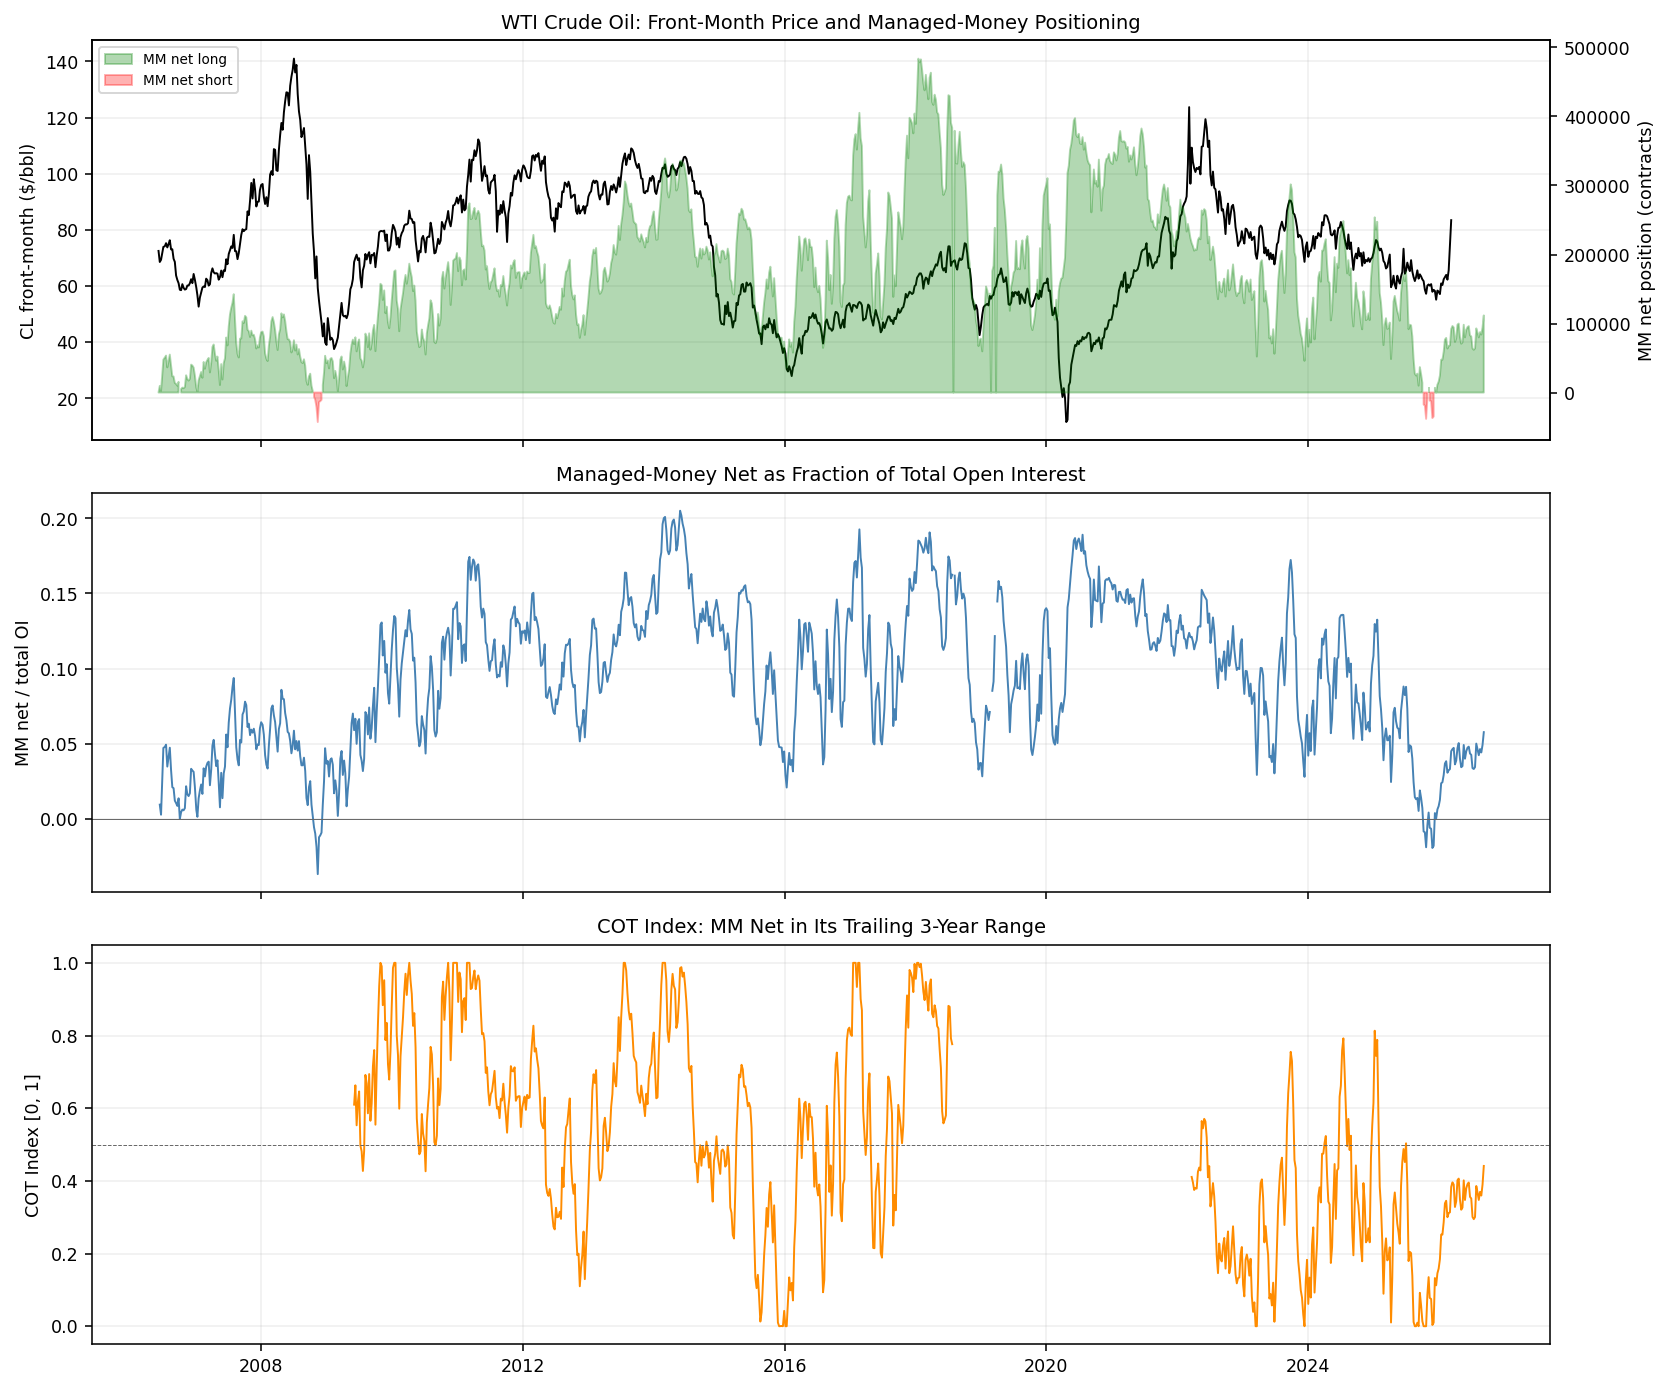

In [11]:
# ── Plot: MM net vs price ──
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ax = axes[0]
ax.plot(wide.index, wide['price'], color='black', lw=1)
ax.set_ylabel('CL front-month ($/bbl)')
ax.set_title('WTI Crude Oil: Front-Month Price and Managed-Money Positioning')
ax.grid(alpha=0.2)

ax2 = ax.twinx()
_mm = wide['MM_net'].fillna(0)
ax2.fill_between(wide.index, _mm, 0,
                 where=_mm >= 0, color='green', alpha=0.3, label='MM net long')
ax2.fill_between(wide.index, _mm, 0,
                 where=_mm < 0, color='red', alpha=0.3, label='MM net short')
ax2.set_ylabel('MM net position (contracts)')
ax2.legend(loc='upper left', fontsize=7)

ax = axes[1]
ax.plot(wide.index, wide['MM_net_frac'], color='steelblue', lw=1)
ax.axhline(0, color='0.4', lw=0.5)
ax.set_ylabel('MM net / total OI')
ax.set_title('Managed-Money Net as Fraction of Total Open Interest')
ax.grid(alpha=0.2)

ax = axes[2]
ax.plot(wide.index, wide['COT_index'], color='darkorange', lw=1)
ax.axhline(0.5, color='0.4', lw=0.5, ls='--')
ax.set_ylabel('COT Index [0, 1]')
ax.set_title('COT Index: MM Net in Its Trailing 3-Year Range')
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()


**Answer (b):** Managed-money net position is $MM_L-MM_S$. I normalize it by total open interest to remove part of the secular scale change in the futures market. The COT index measures the current net position relative to its **full trailing three-year range**, so values near 1 are near the trailing maximum and values near 0 are near the trailing minimum.

The overlay shows that managed money is broadly net long during bull markets and reduces or flips short during major selloffs (2008, 2014–16, 2020), consistent with trend-following behavior dominating the managed-money category. For the price overlay I use a non-overlapping nearby contract and a bounded prior-settlement match around holidays. The chart is descriptive: co-movement between price and positioning is economically interesting, but it does not identify causal direction.

**COT-index sample audit.** The implementation deliberately requires 156 consecutive report rows with valid managed-money positions and does not interpolate missing CFTC observations. The audit cell prints every missing `MM_net` report date and separates the mechanical 155-row warm-up from any later windows invalidated by missing reports (and from the zero-range edge case). This makes the smaller COT-index regression sample explicit rather than silently dropping observations.


## (c) Hedging pressure

Fraction of weeks commercials are net short (HP > 0): 96.7%
Mean HP: 0.1575
Median HP: 0.1674


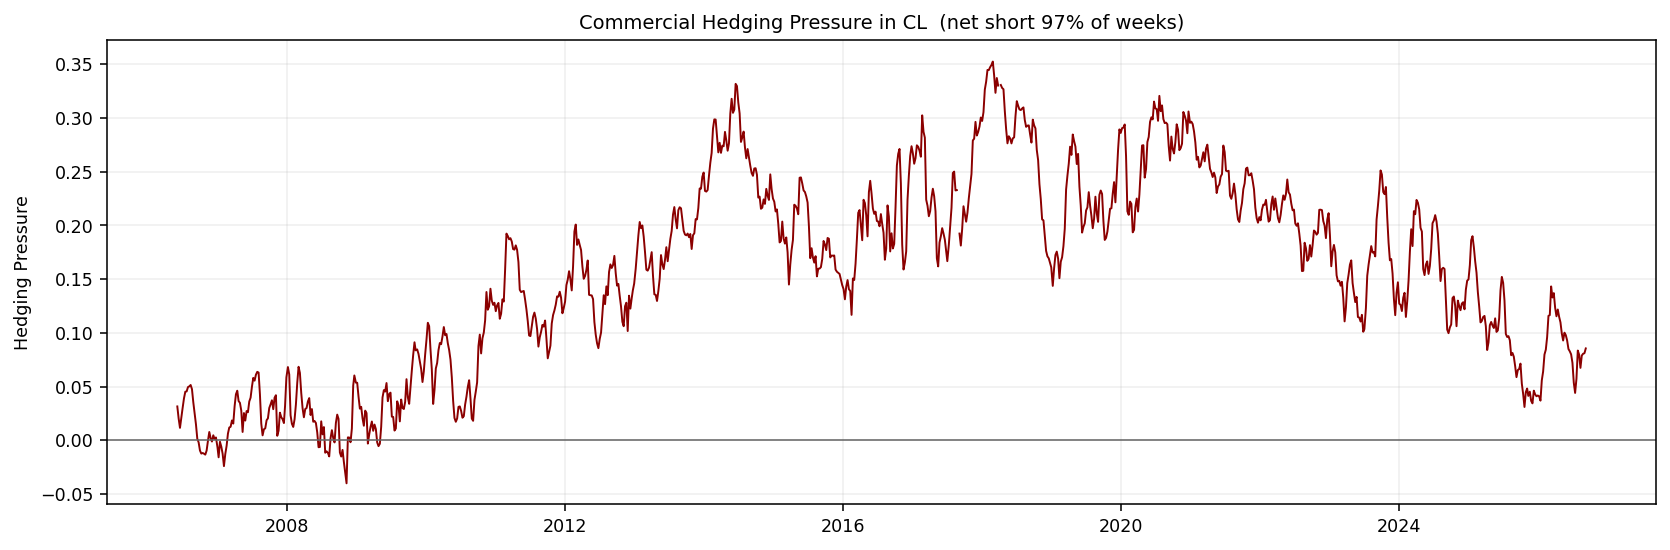

In [12]:
# Hedging pressure: HP = (CM_S - CM_L) / (CM_S + CM_L)
wide['HP'] = (wide['CM_S'] - wide['CM_L']) / (wide['CM_S'] + wide['CM_L'])

frac_net_short = (wide['HP'] > 0).mean()
print(f'Fraction of weeks commercials are net short (HP > 0): {frac_net_short:.1%}')
print(f'Mean HP: {wide["HP"].mean():.4f}')
print(f'Median HP: {wide["HP"].median():.4f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wide.index, wide['HP'], color='darkred', lw=1)
ax.axhline(0, color='0.4', lw=0.8)
ax.set_ylabel('Hedging Pressure')
ax.set_title(f'Commercial Hedging Pressure in CL  '
             f'(net short {frac_net_short:.0%} of weeks)')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


**Answer (c):** The fraction printed above is the share of weeks in which commercials are net short. A value near the historical result of roughly 97% is economically plausible in crude oil because producers and merchants frequently sell futures to hedge physical inventory or future production. The near-100% frequency reflects the dominance of upstream producers (E&P companies, national oil companies) on the commercial short side, whose aggregate hedging volume far exceeds consumer and refiner hedging on the long side. HP is usually positive and fairly stable, with only a small number of weeks in which commercials become net long. Those exceptions are consistent with unusual physical-market and hedging conditions, but the COT data alone do not identify the particular curve or fundamental mechanism behind each episode. Consumers and refiners can hedge on the long side, so the commercial category is the net of several motives; the persistent net-short sign is a positioning fact, not by itself proof of a risk premium or a causal price effect.

## (d) Contemporaneous correlation: speculators moving the price, or the price moving speculators?

n = 1023
Contemporaneous correlation: +0.3959
Regression slope: 1,497.2 contracts per 1% return
OLS t-stat of slope: +13.78
R² = 0.1568


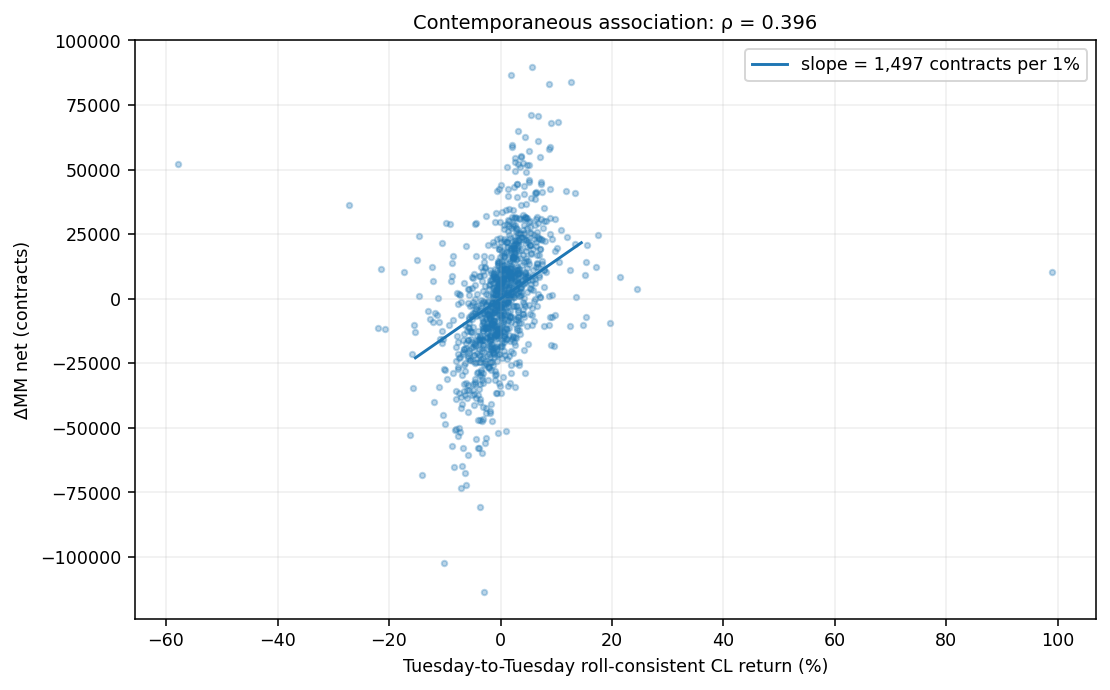

In [13]:
# Tuesday-to-Tuesday return of the continuously rolled nearby strategy.
# The target-date matcher handles short exchange-calendar gaps, while the
# underlying return index removes contract-level jumps at rolls.
tue_ri_match = bounded_asof(
    wide.index, front_return_index, max_age_days=3, value_name='return_index'
)
wide['return_index_tue'] = tue_ri_match['return_index'].to_numpy()
wide['return_index_tue_date'] = tue_ri_match['obs_date'].to_numpy()
wide['return_index_tue_age_days'] = tue_ri_match['age_days'].to_numpy()
wide['ret_tue'] = wide['return_index_tue'].pct_change(fill_method=None)
wide['dMM_net'] = wide['MM_net'].diff()

df_contemp = (wide[['ret_tue', 'dMM_net']]
              .replace([np.inf, -np.inf], np.nan)
              .dropna())

corr = df_contemp['ret_tue'].corr(df_contemp['dMM_net'])
x_pct = df_contemp['ret_tue'] * 100.0   # one unit = one percentage point
y = df_contemp['dMM_net']
slope, intercept, r, p, se = sp_stats.linregress(x_pct, y)

print(f'n = {len(df_contemp)}')
print(f'Contemporaneous correlation: {corr:+.4f}')
print(f'Regression slope: {slope:,.1f} contracts per 1% return')
print(f'OLS t-stat of slope: {slope / se:+.2f}')
print(f'R² = {r**2:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_pct, y, alpha=0.3, s=8)
xf = np.linspace(x_pct.quantile(0.01), x_pct.quantile(0.99), 100)
ax.plot(xf, intercept + slope * xf, lw=1.5,
        label=f'slope = {slope:,.0f} contracts per 1%')
ax.set_xlabel('Tuesday-to-Tuesday roll-consistent CL return (%)')
ax.set_ylabel('ΔMM net (contracts)')
ax.set_title(f'Contemporaneous association: ρ = {corr:.3f}')
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


In [14]:
def correlation_diagnostics(x, y, hac_lags=4):
    """Correlation plus iid and HAC slope t-stats for a weekly diagnostic."""
    tmp = pd.concat([x.rename('x'), y.rename('y')], axis=1).dropna()
    n = len(tmp)
    if n < 3:
        return np.nan, np.nan, np.nan, n

    rho = tmp['x'].corr(tmp['y'])
    X = sm.add_constant(tmp['x'].to_numpy(dtype=float))
    Y = tmp['y'].to_numpy(dtype=float)
    iid = sm.OLS(Y, X).fit()
    hac = sm.OLS(Y, X).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': hac_lags, 'use_correction': True},
    )
    return rho, iid.tvalues[1], hac.tvalues[1], n

checks = [
    ('same week: ret[t] vs dMM[t]', wide['ret_tue'], wide['dMM_net']),
    ('price leads one week: ret[t-1] vs dMM[t]', wide['ret_tue'].shift(1), wide['dMM_net']),
    ('positioning leads one week: dMM[t-1] vs ret[t]', wide['dMM_net'].shift(1), wide['ret_tue']),
]

# Four weekly HAC lags are a one-month robustness diagnostic.  These lead/lag
# regressions are descriptive; no causal direction is inferred from them.
LEADLAG_HAC_LAGS = 4
leadlag = []
for label, x, y in checks:
    rho_i, iid_t_i, hac_t_i, n_i = correlation_diagnostics(
        x, y, hac_lags=LEADLAG_HAC_LAGS
    )
    leadlag.append({
        'channel': label,
        'rho': rho_i,
        'iid_t_diagnostic': iid_t_i,
        'HAC_t_diagnostic': hac_t_i,
        'HAC_lags': LEADLAG_HAC_LAGS,
        'n': n_i,
    })
leadlag = pd.DataFrame(leadlag)

display(leadlag.style.format({
    'rho': '{:+.4f}',
    'iid_t_diagnostic': '{:+.2f}',
    'HAC_t_diagnostic': '{:+.2f}',
    'HAC_lags': '{:,.0f}',
    'n': '{:,.0f}',
}))

strongest = leadlag.iloc[leadlag['rho'].abs().argmax()]
print(f'Largest absolute correlation: {strongest["channel"]} ({strongest["rho"]:+.4f})')


,channel,rho,iid_t_diagnostic,HAC_t_diagnostic,HAC_lags,n
0,same week: ret[t] vs dMM[t],+0.3959,+13.78,+2.86,4,"1,023"
1,price leads one week: ret[t-1] vs dMM[t],+0.0579,+1.85,+1.34,4,"1,024"
2,positioning leads one week: dMM[t-1] vs ret[t],+0.0706,+2.26,+1.38,4,"1,022"


Largest absolute correlation: same week: ret[t] vs dMM[t] (+0.3959)


**Answer (d):** The contemporaneous correlation and the slope in **contracts per 1% return** are reported above. I also show one-week lead/lag correlations as a diagnostic, with both the textbook iid t-statistic and a four-week HAC/Newey-West diagnostic t-statistic. Returns are measured on a self-financing nearby-contract return index, so a calendar-spread jump at a roll is not counted as an outright crude-oil return.

The key distinction is between economic interpretation and causal identification. If the contemporaneous association is larger than either lagged channel, the weekly data look more concurrent than sequential: price and positioning are moving together during the same reporting interval. Weak positioning-leads-price correlation provides little support for a strong weekly predictive channel from managed-money positioning to the next week's return, while weak price-leads-positioning correlation likewise gives little evidence of a simple one-week delayed response. This is consistent with adjustment occurring within the week or with both variables reacting to common information. These correlations alone cannot establish which side causes the other.


The lead/lag t-statistics are **diagnostic rather than causal inference**; the HAC column is included so the qualitative comparison does not rely on an iid weekly-data assumption.


## (e) Predictive regressions

In [15]:
# Assignment convention: returns begin on the Friday after the Tuesday COT
# snapshot.  Exact calendar horizons are matched to the latest prior return-index
# observation within three calendar days.
wide['friday'] = pd.DatetimeIndex(wide.index) + pd.offsets.Week(weekday=4)

start_match = bounded_asof(
    wide['friday'], front_return_index, max_age_days=3, value_name='return_index'
)
wide['return_index_fri'] = start_match['return_index'].to_numpy()
wide['return_index_fri_date'] = start_match['obs_date'].to_numpy()
wide['return_index_fri_age_days'] = start_match['age_days'].to_numpy()

for h in [1, 4, 13]:
    target_end = wide['friday'] + pd.to_timedelta(7 * h, unit='D')
    end_match = bounded_asof(
        target_end, front_return_index, max_age_days=3, value_name='return_index'
    )

    wide[f'end_target_{h}w'] = target_end
    wide[f'end_return_index_{h}w'] = end_match['return_index'].to_numpy()
    wide[f'end_return_index_date_{h}w'] = end_match['obs_date'].to_numpy()
    wide[f'end_age_days_{h}w'] = end_match['age_days'].to_numpy()

    valid = (wide['return_index_fri'].notna() &
             wide[f'end_return_index_{h}w'].notna() &
             (wide[f'end_return_index_date_{h}w'] > wide['return_index_fri_date']))

    wide[f'fwd_ret_{h}w'] = np.nan
    wide.loc[valid, f'fwd_ret_{h}w'] = (
        wide.loc[valid, f'end_return_index_{h}w'] /
        wide.loc[valid, 'return_index_fri'] - 1.0
    )

# Tradable-timing robustness: the COT report is published after the Friday CL
# settlement.  With daily data, use the first settlement STRICTLY after that
# Friday as the first certainly observable post-publication price.  Then hold
# for the same h calendar weeks from that observed start date.
post_start = bounded_forward_after(
    wide['friday'], front_return_index, max_delay_days=4,
    value_name='post_release_return_index'
)
wide['post_release_start_index'] = post_start['post_release_return_index'].to_numpy()
wide['post_release_start_date'] = post_start['obs_date'].to_numpy()
wide['post_release_start_delay_days'] = post_start['delay_days'].to_numpy()

for h in [1, 4, 13]:
    post_target_end = pd.to_datetime(wide['post_release_start_date']) + pd.to_timedelta(7 * h, unit='D')
    post_end_match = bounded_asof(
        post_target_end, front_return_index, max_age_days=3,
        value_name='post_release_end_index'
    )
    wide[f'post_end_target_{h}w'] = post_target_end
    wide[f'post_end_index_{h}w'] = post_end_match['post_release_end_index'].to_numpy()
    wide[f'post_end_date_{h}w'] = post_end_match['obs_date'].to_numpy()
    wide[f'post_end_age_days_{h}w'] = post_end_match['age_days'].to_numpy()

    valid = (wide['post_release_start_index'].notna() &
             wide[f'post_end_index_{h}w'].notna() &
             (wide[f'post_end_date_{h}w'] > wide['post_release_start_date']))
    wide[f'post_fwd_ret_{h}w'] = np.nan
    wide.loc[valid, f'post_fwd_ret_{h}w'] = (
        wide.loc[valid, f'post_end_index_{h}w'] /
        wide.loc[valid, 'post_release_start_index'] - 1.0
    )

print('Roll-return index history:', front_return_index.index.min().date(), 'to',
      front_return_index.index.max().date())
print('Last COT snapshot:', wide.index.max().date())
print('Friday assignment-start match ages:')
print(wide['return_index_fri_age_days'].value_counts(dropna=False).sort_index().to_string())
print('Post-release start delays (strictly after Friday):')
print(wide['post_release_start_delay_days'].value_counts(dropna=False).sort_index().to_string())


Roll-return index history: 2006-06-01 to 2026-03-13
Last COT snapshot: 2026-09-08
Friday assignment-start match ages:
return_index_fri_age_days
0.0    998
1.0     32
2.0      1
NaN     26
Post-release start delays (strictly after Friday):
post_release_start_delay_days
3.0    931
4.0     97
NaN     29


In [16]:
signals = [
    ('MM net / OI', 'MM_net_frac'),
    ('COT index', 'COT_index'),
    ('Hedging pressure', 'HP'),
]


def run_predictive_regressions(return_prefix):
    """Three signals x three horizons with OLS and overlap-aware HAC inference."""
    results = []
    for sig_name, sig_col in signals:
        for h in [1, 4, 13]:
            ret_col = return_prefix.format(h=h)
            tmp = (wide[[sig_col, ret_col]]
                   .replace([np.inf, -np.inf], np.nan)
                   .dropna()
                   .copy())
            if len(tmp) < 30:
                continue

            sig_sd = tmp[sig_col].std(ddof=1)
            if not np.isfinite(sig_sd) or sig_sd == 0:
                continue

            x = (tmp[sig_col] - tmp[sig_col].mean()) / sig_sd
            y = tmp[ret_col]
            X = sm.add_constant(x.to_numpy(dtype=float))

            ols = sm.OLS(y.to_numpy(dtype=float), X).fit()
            hac_lags = max(h - 1, 0)
            hac = sm.OLS(y.to_numpy(dtype=float), X).fit(
                cov_type='HAC',
                cov_kwds={'maxlags': hac_lags, 'use_correction': True},
            )

            results.append({
                'signal': sig_name,
                'horizon_weeks': h,
                'n': len(tmp),
                'IC': x.corr(y),
                'slope_pct_per_1sd': 100.0 * ols.params[1],
                'OLS_t': ols.tvalues[1],
                'HAC_t': hac.tvalues[1],
                'HAC_lags': hac_lags,
            })
    return (pd.DataFrame(results)
            .sort_values(['signal', 'horizon_weeks'])
            .reset_index(drop=True))


fmt = {
    'IC': '{:+.4f}'.format,
    'slope_pct_per_1sd': '{:+.3f}'.format,
    'OLS_t': '{:+.2f}'.format,
    'HAC_t': '{:+.2f}'.format,
}

# Primary table: exact Friday convention requested by the assignment.
res_df = run_predictive_regressions('fwd_ret_{h}w')
print('Assignment convention: Friday-to-horizon returns')
display(res_df.assign(**{c: res_df[c].map(f) for c, f in fmt.items()}))

# Robustness table: first daily settlement strictly after Friday publication.
res_post_df = run_predictive_regressions('post_fwd_ret_{h}w')
print('Post-release robustness: first settlement strictly after release Friday')
display(res_post_df.assign(**{c: res_post_df[c].map(f) for c, f in fmt.items()}))

# Side-by-side timing sensitivity for the two inference conventions.
timing_compare = res_df.merge(
    res_post_df,
    on=['signal', 'horizon_weeks'],
    suffixes=('_assignment', '_postrelease'),
    how='outer',
)
cols = [
    'signal', 'horizon_weeks',
    'n_assignment', 'IC_assignment', 'HAC_t_assignment',
    'n_postrelease', 'IC_postrelease', 'HAC_t_postrelease',
]
print('Timing-robustness comparison')
display(timing_compare[cols].style.format({
    'IC_assignment': '{:+.4f}',
    'HAC_t_assignment': '{:+.2f}',
    'IC_postrelease': '{:+.4f}',
    'HAC_t_postrelease': '{:+.2f}',
    'n_assignment': '{:,.0f}',
    'n_postrelease': '{:,.0f}',
}))


Assignment convention: Friday-to-horizon returns


,signal,horizon_weeks,n,IC,slope_pct_per_1sd,OLS_t,HAC_t,HAC_lags
0,COT index,1,684,-0.0333,-0.149,-0.87,-0.87,0
1,COT index,4,681,-0.0494,-0.418,-1.29,-0.89,3
2,COT index,13,672,-0.1103,-1.532,-2.87,-1.22,12
3,Hedging pressure,1,1028,-0.0074,-0.040,-0.24,-0.24,0
4,Hedging pressure,4,1025,-0.0031,-0.034,-0.10,-0.06,3
5,Hedging pressure,13,1016,-0.0167,-0.331,-0.53,-0.15,12
6,MM net / OI,1,1026,+0.0140,+0.075,+0.45,+0.43,0
7,MM net / OI,4,1023,+0.0283,+0.313,+0.91,+0.52,3
8,MM net / OI,13,1014,-0.0303,-0.603,-0.96,-0.30,12


Post-release robustness: first settlement strictly after release Friday


,signal,horizon_weeks,n,IC,slope_pct_per_1sd,OLS_t,HAC_t,HAC_lags
0,COT index,1,684,-0.0467,-0.215,-1.22,-1.19,0
1,COT index,4,680,-0.0450,-0.369,-1.17,-0.80,3
2,COT index,13,672,-0.1146,-1.606,-2.99,-1.27,12
3,Hedging pressure,1,1025,-0.0019,-0.011,-0.06,-0.06,0
4,Hedging pressure,4,1022,+0.0055,+0.065,+0.18,+0.10,3
5,Hedging pressure,13,1014,-0.0134,-0.282,-0.43,-0.12,12
6,MM net / OI,1,1023,+0.0086,+0.050,+0.28,+0.30,0
7,MM net / OI,4,1020,+0.0289,+0.341,+0.92,+0.57,3
8,MM net / OI,13,1012,-0.0375,-0.786,-1.19,-0.38,12


Timing-robustness comparison


,signal,horizon_weeks,n_assignment,IC_assignment,HAC_t_assignment,n_postrelease,IC_postrelease,HAC_t_postrelease
0,COT index,1,684,-0.0333,-0.87,684,-0.0467,-1.19
1,COT index,4,681,-0.0494,-0.89,680,-0.0450,-0.80
2,COT index,13,672,-0.1103,-1.22,672,-0.1146,-1.27
3,Hedging pressure,1,"1,028",-0.0074,-0.24,"1,025",-0.0019,-0.06
4,Hedging pressure,4,"1,025",-0.0031,-0.06,"1,022",+0.0055,+0.10
5,Hedging pressure,13,"1,016",-0.0167,-0.15,"1,014",-0.0134,-0.12
6,MM net / OI,1,"1,026",+0.0140,+0.43,"1,023",+0.0086,+0.30
7,MM net / OI,4,"1,023",+0.0283,+0.52,"1,020",+0.0289,+0.57
8,MM net / OI,13,"1,014",-0.0303,-0.30,"1,012",-0.0375,-0.38


In [17]:
# Alignment / stale-data audit.  Fail explicitly if timing invariants are violated.
audit_rows = []
post_audit_rows = []
for h in [1, 4, 13]:
    valid = wide[f'fwd_ret_{h}w'].notna()
    if valid.any():
        starts = wide.loc[valid, 'friday']
        start_obs_dates = pd.to_datetime(wide.loc[valid, 'return_index_fri_date'])
        ends = pd.to_datetime(wide.loc[valid, f'end_target_{h}w'])
        end_obs_dates = pd.to_datetime(wide.loc[valid, f'end_return_index_date_{h}w'])

        assert (start_obs_dates <= starts).all()
        assert (end_obs_dates <= ends).all()
        assert ((starts - start_obs_dates).dt.days <= 3).all()
        assert ((ends - end_obs_dates).dt.days <= 3).all()
        assert (end_obs_dates > start_obs_dates).all()
        assert (end_obs_dates <= front_return_index.index.max()).all()

        audit_rows.append({
            'horizon_weeks': h,
            'n_returns': int(valid.sum()),
            'last_start_target': starts.max().date(),
            'last_end_observation': end_obs_dates.max().date(),
            'max_start_age_days': int((starts - start_obs_dates).dt.days.max()),
            'max_end_age_days': int((ends - end_obs_dates).dt.days.max()),
        })

    pvalid = wide[f'post_fwd_ret_{h}w'].notna()
    if pvalid.any():
        release_fridays = pd.to_datetime(wide.loc[pvalid, 'friday'])
        post_starts = pd.to_datetime(wide.loc[pvalid, 'post_release_start_date'])
        post_targets = pd.to_datetime(wide.loc[pvalid, f'post_end_target_{h}w'])
        post_ends = pd.to_datetime(wide.loc[pvalid, f'post_end_date_{h}w'])

        assert (post_starts > release_fridays).all()
        assert ((post_starts - release_fridays).dt.days.between(1, 4)).all()
        assert (post_ends <= post_targets).all()
        assert ((post_targets - post_ends).dt.days.between(0, 3)).all()
        assert (post_ends > post_starts).all()
        assert (post_ends <= front_return_index.index.max()).all()

        post_audit_rows.append({
            'horizon_weeks': h,
            'n_returns': int(pvalid.sum()),
            'max_release_to_start_days': int((post_starts - release_fridays).dt.days.max()),
            'max_end_age_days': int((post_targets - post_ends).dt.days.max()),
            'last_start_observation': post_starts.max().date(),
            'last_end_observation': post_ends.max().date(),
        })

print('Assignment-timing alignment audit')
audit_df = pd.DataFrame(audit_rows)
display(audit_df)
print('Post-release timing alignment audit')
post_release_audit_df = pd.DataFrame(post_audit_rows)
display(post_release_audit_df)


Assignment-timing alignment audit


,horizon_weeks,n_returns,last_start_target,last_end_observation,max_start_age_days,max_end_age_days
0,1,1030,2026-03-06,2026-03-13,2,2
1,4,1027,2026-02-13,2026-03-13,2,2
2,13,1018,2025-12-12,2026-03-13,2,2


Post-release timing alignment audit


,horizon_weeks,n_returns,max_release_to_start_days,max_end_age_days,last_start_observation,last_end_observation
0,1,1027,4,3,2026-03-09,2026-03-13
1,4,1024,4,3,2026-02-09,2026-03-09
2,13,1016,4,3,2025-12-15,2026-03-13


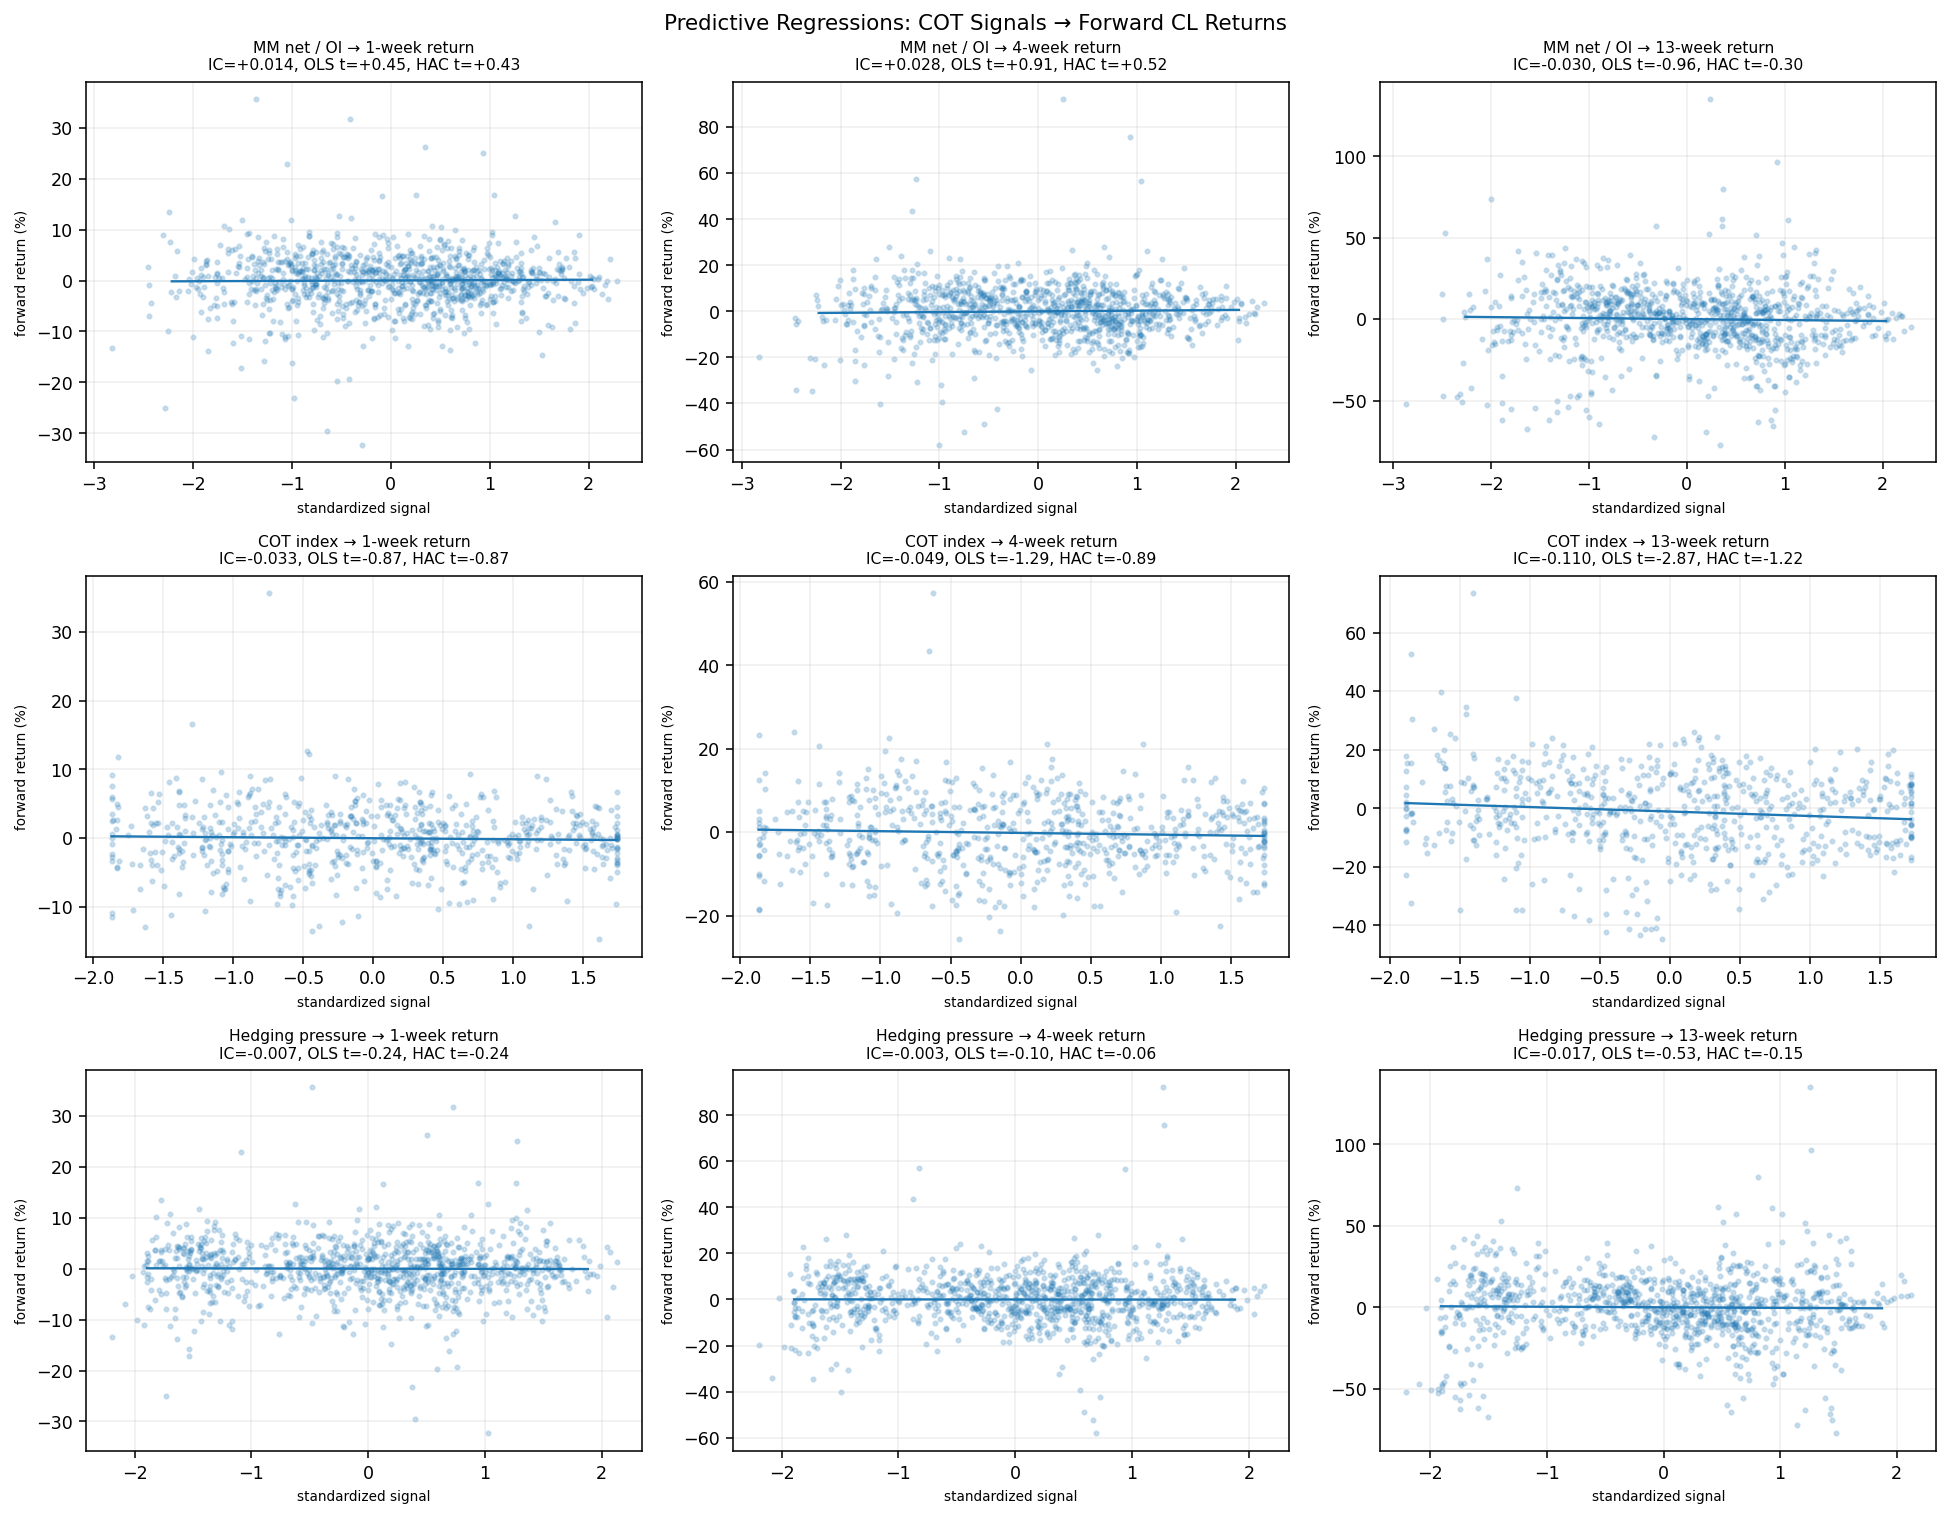

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))

for j, (sig_name, sig_col) in enumerate(signals):
    for k, h in enumerate([1, 4, 13]):
        ax = axes[j, k]
        ret_col = f'fwd_ret_{h}w'
        tmp = wide[[sig_col, ret_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()

        if len(tmp) < 30 or tmp[sig_col].std(ddof=1) == 0:
            ax.set_axis_off()
            continue

        x = (tmp[sig_col] - tmp[sig_col].mean()) / tmp[sig_col].std(ddof=1)
        y_pct = tmp[ret_col] * 100.0
        slope_i, intercept_i, _, _, _ = sp_stats.linregress(x, y_pct)

        ax.scatter(x, y_pct, alpha=0.2, s=5)
        xf = np.linspace(x.quantile(0.01), x.quantile(0.99), 50)
        ax.plot(xf, intercept_i + slope_i * xf, lw=1.2)

        row = res_df[(res_df['signal'].eq(sig_name)) &
                     (res_df['horizon_weeks'].eq(h))]
        if not row.empty:
            row = row.iloc[0]
            ax.set_title(f'{sig_name} → {h}-week return\n'
                         f'IC={row.IC:+.3f}, OLS t={row.OLS_t:+.2f}, HAC t={row.HAC_t:+.2f}',
                         fontsize=8)
        ax.set_xlabel('standardized signal', fontsize=7)
        ax.set_ylabel('forward return (%)', fontsize=7)
        ax.grid(alpha=0.2)

fig.suptitle('Predictive Regressions: COT Signals → Forward CL Returns', fontsize=11)
fig.tight_layout()
plt.show()


**Answer (e):** The table above reports the requested information coefficient and slope t-statistic for each signal at 1-, 4-, and 13-week horizons. I report the ordinary **OLS t-statistic** because it is the direct regression output, and I also report a **HAC/Newey-West t-statistic** as a robustness check. The 4- and 13-week dependent variables overlap across adjacent weekly observations, so their regression residuals can inherit serial dependence mechanically; the overlap-motivated HAC bandwidth is $h-1$ lags.

The IC is unaffected by the standard-error choice. Small absolute ICs should be interpreted as weak predictive relationships even if one conventional t-stat crosses a threshold. The COT-index 13-week horizon is a concrete illustration: its OLS t of −2.87 would appear significant at conventional levels, but the HAC t of −1.22 shows that this significance is not robust once the serial dependence induced by overlapping returns is accounted for. The point estimate and IC are unchanged; the evidence is simply too imprecise to support a strong predictive claim. Statistical predictability is also different from an implementable trading strategy: transaction costs, margin/capital conventions, release timing, roll execution, and out-of-sample stability remain separate questions.

**Alignment and return construction:** each Tuesday COT observation is assigned to the following Friday target date. If that Friday is a market holiday, I use only the most recent return-index observation within three calendar days; I never carry an observation across a long gap or beyond the end of available market data. Endpoints are exact calendar horizons of 1, 4, and 13 weeks from that Friday target. The dependent variable is the return of a continuously rolled nearby CL strategy: when the active contract changes, the incoming contract is compared with its own settlement on the prior roll anchor, so the old/new calendar-spread level difference is not misclassified as outright return.

**Information-availability robustness.** The first regression table follows the assignment's Friday convention. A second table starts at the **first daily CL settlement strictly after the Friday publication date**, which is the first daily settlement that is certainly observable after the report is public. This does not replace the assignment specification; it is a tradability/timing robustness check. The final write-up should report whether the HAC conclusion changes under this post-release convention.


In [19]:
# Final Q1 checks.
assert not front.index.duplicated().any()
assert wide['COT_index'].dropna().between(0, 1).all()
assert wide['price_age_days'].dropna().between(0, 3).all()
assert wide['return_index_tue_age_days'].dropna().between(0, 3).all()
assert wide['return_index_fri_age_days'].dropna().between(0, 3).all()
assert front_return_index.index.is_monotonic_increasing
assert not front_return_index.index.duplicated().any()
assert front_return_index.notna().all()
assert front_daily_ret.iloc[1:].notna().all()

if not roll_return_audit.empty:
    assert roll_return_audit['anchor_age_days'].between(0, 3).all()
    assert (roll_return_audit['anchor_date'] <=
            roll_return_audit['scheduled_roll_date']).all()

for h in [1, 4, 13]:
    assert wide[f'end_age_days_{h}w'].dropna().between(0, 3).all()
    valid = wide[f'fwd_ret_{h}w'].notna()
    if valid.any():
        assert (pd.to_datetime(wide.loc[valid, f'end_return_index_date_{h}w']) >
                pd.to_datetime(wide.loc[valid, 'return_index_fri_date'])).all()

assert wide['post_release_start_delay_days'].dropna().between(1, 4).all()
for h in [1, 4, 13]:
    assert wide[f'post_end_age_days_{h}w'].dropna().between(0, 3).all()
    valid = wide[f'post_fwd_ret_{h}w'].notna()
    if valid.any():
        assert (pd.to_datetime(wide.loc[valid, 'post_release_start_date']) >
                pd.to_datetime(wide.loc[valid, 'friday'])).all()
        assert (pd.to_datetime(wide.loc[valid, f'post_end_date_{h}w']) >
                pd.to_datetime(wide.loc[valid, 'post_release_start_date'])).all()

print('Snapshot caps:')
print(f'  COT <= {COT_AS_OF_DATE:%Y-%m-%d}; SHA256={COT_SHA256}')
print(f'  CL settlements <= {CL_AS_OF_DATE:%Y-%m-%d}; SHA256={CL_PRICE_SHA256}')
print('Q1 data, roll, attrition, and timing checks passed.')


Snapshot caps:
  COT <= 2026-09-08; SHA256=967457209b6c825bcc3de72c25375a52f20da679963b820ec9ddd53b7c2b6a1f
  CL settlements <= 2026-04-03; SHA256=e1e6fe9e06b28c724596f375d9bbfe53eb4f91ccd3a4855b3ead2b0ddb0cf126
Q1 data, roll, attrition, and timing checks passed.


In [20]:
conn.close()
print('WRDS connection closed.')


WRDS connection closed.


---
# Question 2 — Seasonal Calendar Spreads into Expiry
---

In [21]:
# Question 2 uses the instructor-supplied futspread package AS PROVIDED.
# Do not patch or replace the package to run this notebook.
PROJECT_DIR = Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import futspread
from futspread import (
    build_combo, load_combo, condense, summary, stats,
    plot_combo, parse_combo, download,
)

print(f'Instructor futspread loaded from: {Path(futspread.__file__).resolve()}')
print(f'download signature: {inspect.signature(download)}')
print('Instructor package is used unchanged; notebook-level audits below enforce '
      'the assignment-specific full-window requirement.')

for spread_code in ['NG[H][J0]', 'ZC[U][Z0]', 'ZW[K][N0]', 'HE[V][Z0]']:
    print(parse_combo(spread_code))


def print_spread_diagnostics(cond, per, st, expected_direction):
    # Print cross-year statistics, hypothesis agreement, exceptions, and timing.
    if expected_direction not in {'down', 'up'}:
        raise ValueError("expected_direction must be 'down' or 'up'")

    pnl = per['pnl'].dropna()
    if expected_direction == 'down':
        agrees = pnl < 0
        exceptions = per.loc[per['pnl'] > 0, ['instance', 'pnl']]
        agreement_label = 'negative full-window P&L'
        exception_label = 'Positive (opposite-direction) years'
    else:
        agrees = pnl > 0
        exceptions = per.loc[per['pnl'] < 0, ['instance', 'pnl']]
        agreement_label = 'positive full-window P&L'
        exception_label = 'Negative (opposite-direction) years'

    flat = pnl.eq(0)
    n = len(pnl)
    n_agree = int(agrees.sum())
    agreement_rate = n_agree / n if n else np.nan

    print(f"n={st['n']}, mean={st['mean']:.4f}, median={st['median']:.4f}, "
          f"positive_rate={st['hit_rate']:.1%}, t={st['t_stat']:.2f}")
    print(f'Scenario agreement ({agreement_label}): '
          f'{n_agree}/{n} = {agreement_rate:.1%}')
    if flat.any():
        print(f'Exactly flat full-window years: {int(flat.sum())}')

    print(f'\n{exception_label}:')
    if exceptions.empty:
        print('  none')
    else:
        print(exceptions.to_string(index=False))

    landmarks = [x for x in (-120, -60, -40, -20, -10, 0) if x in cond.index]
    timing = cond.loc[landmarks, ['mean', 'median', 'n']].copy()
    print('\nCondensed path at selected trading-day offsets:')
    print(timing.to_string(float_format=lambda x: f'{x:,.4f}'))


def assert_strict_full_window(wide_matrix, window):
    # Notebook-level audit: every retained annual instance must cover every offset.
    lo, hi = window
    assert not wide_matrix.empty
    assert wide_matrix.index.min() == lo
    assert wide_matrix.index.max() == hi
    assert list(wide_matrix.index) == list(range(lo, hi + 1))
    assert wide_matrix.notna().all().all()
    print(f'Strict full-window check passed: {wide_matrix.shape[1]} instances x '
          f'{wide_matrix.shape[0]} offsets [{lo}, {hi}]')


def print_expiry_source_audit(df):
    # Surface the instructor package's terminal-date conventions; do not alter them.
    cols = [c for c in ['instance', 'ltd', 'ltd_is_fnd', 'fnd_is_rule', 'ltd_source']
            if c in df.columns]
    audit = df[cols].drop_duplicates('instance').sort_values('instance')
    print('Instructor-package terminal-date source audit:')
    group_cols = [c for c in ['ltd_source', 'fnd_is_rule'] if c in audit.columns]
    if group_cols:
        display(audit.groupby(group_cols, dropna=False)
                     .size().rename('n_instances').reset_index())
    else:
        display(audit.head())
    return audit


Instructor futspread loaded from: C:\Users\kokoo\Documents\Columbia\4. Fall 2026\IEOR4576E_001_2026_3 - Data-driven Method Finance\HW\HW2\HW2 Code\futspread\__init__.py
download signature: (username: 'str', root=None, tickers=None, sectors=None, min_ltd='2000-01-01', verbose=True) -> 'pd.DataFrame'
Instructor package is used unchanged; notebook-level audits below enforce the assignment-specific full-window requirement.
NG[H][J0]
ZC[U][Z0]
ZW[K][N0]
HE[V][Z0]


### Data download (run once)

Question 2 uses the **instructor-supplied `futspread` package unchanged**. The notebook adds only assignment-specific audits at the notebook level.


In [22]:
# Run once if the four required series are not already in the local futspread store.
# This is the instructor package's original API; no custom as_of_date argument is used.
spread_info = download(WRDS_USER, tickers=['NG', 'ZC', 'ZW', 'HE'])

print('Downloaded/available spread metadata rows:', len(spread_info))
if 'fnd_is_rule' in spread_info.columns:
    print('Instructor-package rule-derived FND count:',
          int(spread_info['fnd_is_rule'].fillna(False).sum()))


Loading library list...
Done
contracts: 988 rows (4 series) -> C:\Users\kokoo\futspread_data\raw\contracts.parquet
  NG   Natural Gas (Henry Hub)              824,641 bars  1997-03-25..2026-04-03
  ZC   Corn                                  92,464 bars  1998-05-15..2026-04-03
  ZW   Wheat (SRW, composite)                78,790 bars  1999-01-27..2026-04-03
  HE   Lean Hogs (composite)                 71,821 bars  1998-08-17..2026-04-03
Downloaded/available spread metadata rows: 988
Instructor-package rule-derived FND count: 74


In [23]:
combos = ['NG[H][J0]', 'ZC[U][Z0]', 'ZW[K][N0]', 'HE[V][Z0]']
for spread_code in combos:
    df = build_combo(spread_code)
    n = df['instance'].nunique() if not df.empty else 0
    print(f'{spread_code}: {n} instances, {len(df):,} rows')


NG[H][J0]: 29 instances, 13,897 rows
ZC[U][Z0]: 28 instances, 12,462 rows
ZW[K][N0]: 28 instances, 11,718 rows
HE[V][Z0]: 27 instances, 8,002 rows


## (a) Natural gas: the winter premium comes out — NG[H][J0]

**(i)** The spread is **`NG[H][J0]`**: long one **March (H)** natural gas, short one **April (J)** of the same contract year. The long leg is March — the last contract of the withdrawal season.


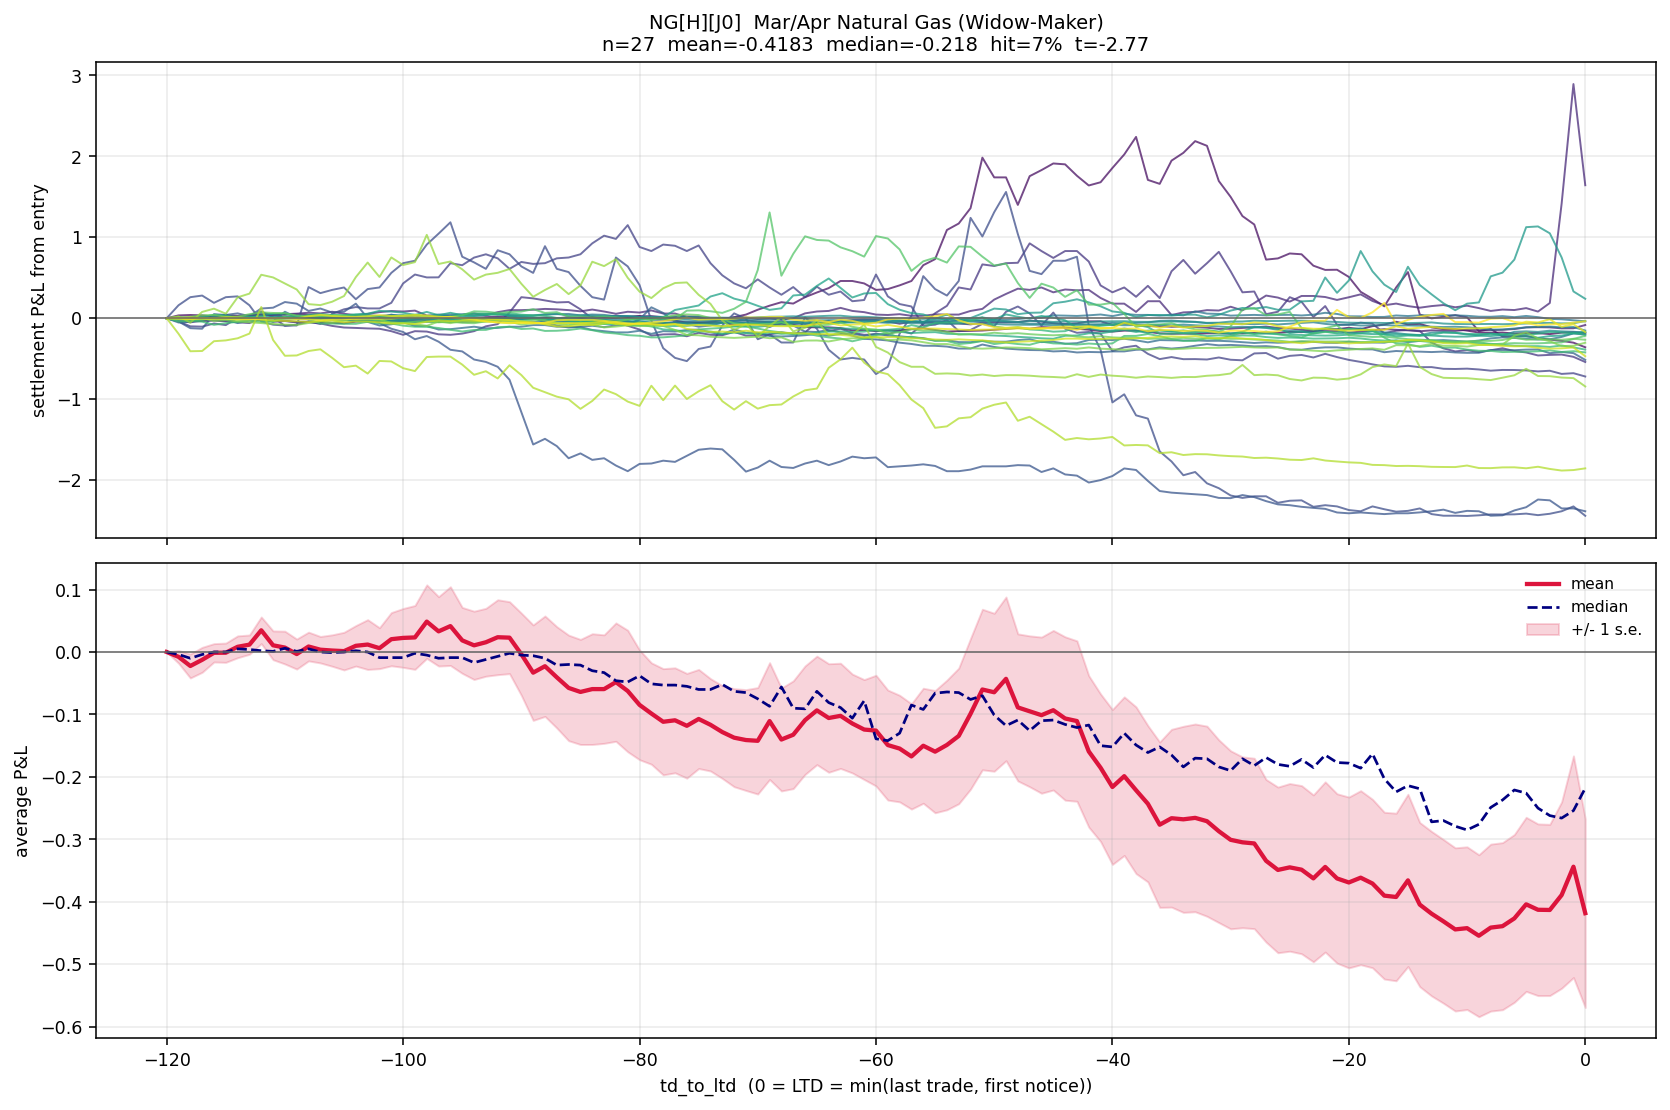

Strict full-window check passed: 27 instances x 121 offsets [-120, 0]
Instructor-package terminal-date source audit:


,ltd_source,fnd_is_rule,n_instances
0,vendor,False,29


n=27, mean=-0.4183, median=-0.2180, positive_rate=7.4%, t=-2.77
Scenario agreement (negative full-window P&L): 25/27 = 92.6%

Positive (opposite-direction) years:
 instance      pnl
     2003 1.643000
     2014 0.240001

Condensed path at selected trading-day offsets:
             mean  median   n
td_to_ltd                    
-120       0.0000  0.0000  27
-60       -0.1259 -0.1390  27
-40       -0.2162 -0.1520  27
-20       -0.3691 -0.1780  27
-10       -0.4423 -0.2850  27
 0        -0.4183 -0.2180  27


In [24]:
df_ng = load_combo('NG[H][J0]')
window_ng = (-120, 0)

fig, (cond_ng, wide_ng, per_ng, st_ng) = plot_combo(
    df_ng, window=window_ng,
    require_full=True, min_coverage=1.0,
    title='NG[H][J0]  Mar/Apr Natural Gas (Widow-Maker)',
    outfile='ng_widow_maker.png',
)
plt.show()

assert_strict_full_window(wide_ng, window_ng)
expiry_audit_ng = print_expiry_source_audit(df_ng)
print_spread_diagnostics(cond_ng, per_ng, st_ng, expected_direction='down')


**(iii) Explanation:**

The mean March/April path is downward into March expiry, which is the expected sign if the end-of-winter scarcity premium in March erodes relative to April as the withdrawal season passes. **25 of 27 years (92.6%)** have a negative full-window P&L, so the cross-year sign agreement is high. Of the 29 historical instances, 27 have full coverage over the (−120, 0) window; the two dropped years (the earliest pair) lack sufficient trading history before their LTDs. The selected-offset table above makes the timing visible numerically rather than relying only on the chart: compare the mean P&L at -60, -40, -20, -10, and 0 trading days.

The two positive exceptions are **2003** and **2014**. Those episodes are consistent with winter scarcity remaining elevated unusually late rather than dissipating normally; 2014 in particular coincided with the severe polar-vortex winter. I treat that as historical economic context, not something established causally by this spread plot.

**(iv) The t-statistic:** `futspread` computes the ordinary one-sample statistic $t=\bar{x}/(s/\sqrt{n})$ across annual window P&Ls. Under the usual sampling assumptions it tests the null that the mean annual P&L is zero. It does not establish causality, profitability after transaction costs, robustness to changing the window, or out-of-sample persistence. With only a few dozen annual observations and fat-tailed commodity outcomes, the magnitude should be interpreted with appropriate caution.

## (b) Corn: going into harvest — ZC[U][Z0]

**(i)** The spread is **`ZC[U][Z0]`**: long one **September (U)** corn, short one **December (Z)** of the same contract year. The long leg is September — the last old-crop contract before the marketing year ends on August 31.


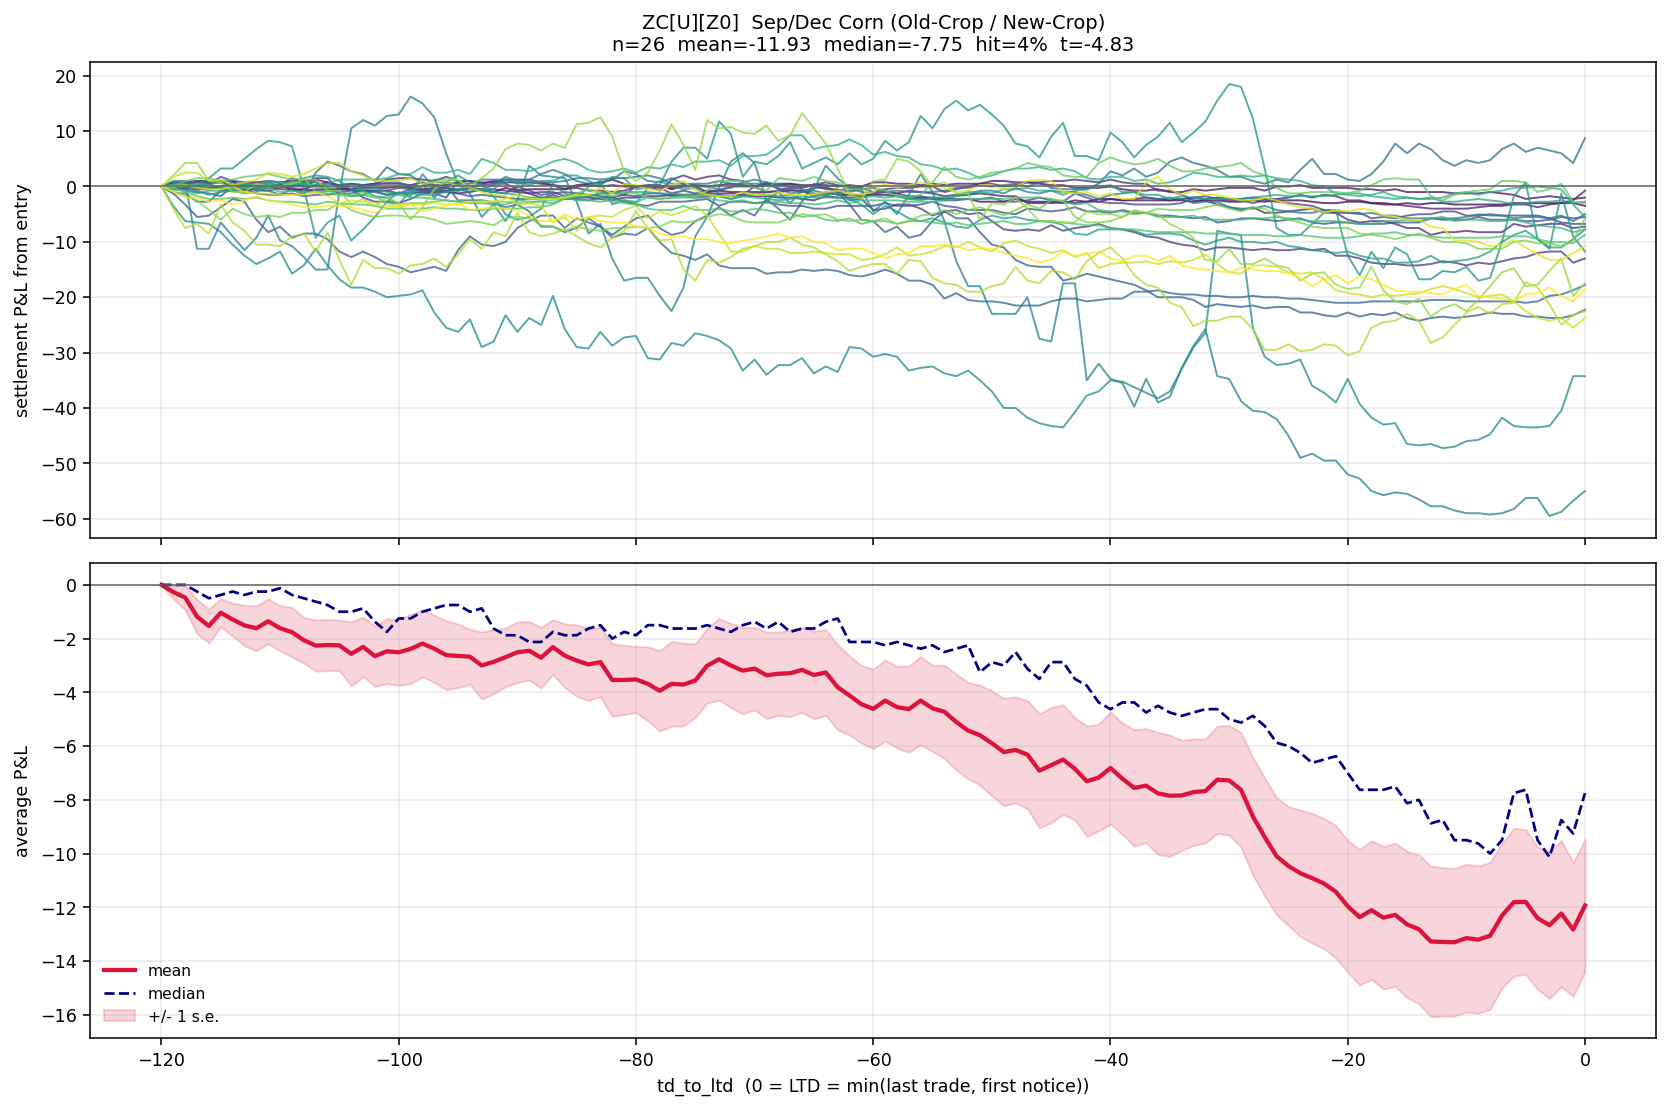

Strict full-window check passed: 26 instances x 121 offsets [-120, 0]
Instructor-package terminal-date source audit:


,ltd_source,fnd_is_rule,n_instances
0,vendor,False,21
1,vendor,True,7


n=26, mean=-11.9327, median=-7.7500, positive_rate=3.8%, t=-4.83
Scenario agreement (negative full-window P&L): 25/26 = 96.2%

Positive (opposite-direction) years:
 instance  pnl
     2009 8.75

Condensed path at selected trading-day offsets:
              mean  median   n
td_to_ltd                     
-120        0.0000  0.0000  26
-60        -4.6154 -2.1250  26
-40        -6.8173 -4.6250  26
-20       -11.9615 -7.0000  26
-10       -13.1442 -9.5000  26
 0        -11.9327 -7.7500  26


In [25]:
df_zc = load_combo('ZC[U][Z0]')
window_zc = (-120, 0)

fig, (cond_zc, wide_zc, per_zc, st_zc) = plot_combo(
    df_zc, window=window_zc,
    require_full=True, min_coverage=1.0,
    title='ZC[U][Z0]  Sep/Dec Corn (Old-Crop / New-Crop)',
    outfile='zc_harvest.png',
)
plt.show()

assert_strict_full_window(wide_zc, window_zc)
expiry_audit_zc = print_expiry_source_audit(df_zc)
print_spread_diagnostics(cond_zc, per_zc, st_zc, expected_direction='down')


**(iii) Explanation:**

The September/December corn spread has a downward mean path into September expiry, matching the old-crop/new-crop mechanism in the question. **25 of 26 years (96.2%)** have a negative full-window P&L. September is the last old-crop contract while December prices the incoming harvest; as harvest becomes more certain and new supply approaches, old-crop scarcity value can be competed away. The selected-offset diagnostics show when that average decline accumulates.

The only positive exception is **2009**. USDA crop reporting for that season described corn development as materially delayed and harvest well behind normal by early autumn. That is economically consistent with new-crop supply arriving later than usual and nearby old-crop value remaining relatively firm. It is context rather than a causal identification from the spread series itself.

**(iv) The t-statistic:** this is the same one-sample test of a zero mean annual-window P&L. A larger absolute t means the sample mean is large relative to its cross-year standard error under the test assumptions; it is not, by itself, evidence of a structural law, after-cost trading profitability, or future persistence.

*Historical context source: USDA NASS, Crop Production, October 2009.*


## (c) Wheat: harvest comes first — ZW[K][N0]

**(i)** The spread is **`ZW[K][N0]`**: long one **May (K)** SRW wheat, short one **July (N)** of the same contract year. The long leg is May — the last old-crop contract before the winter wheat harvest in June.


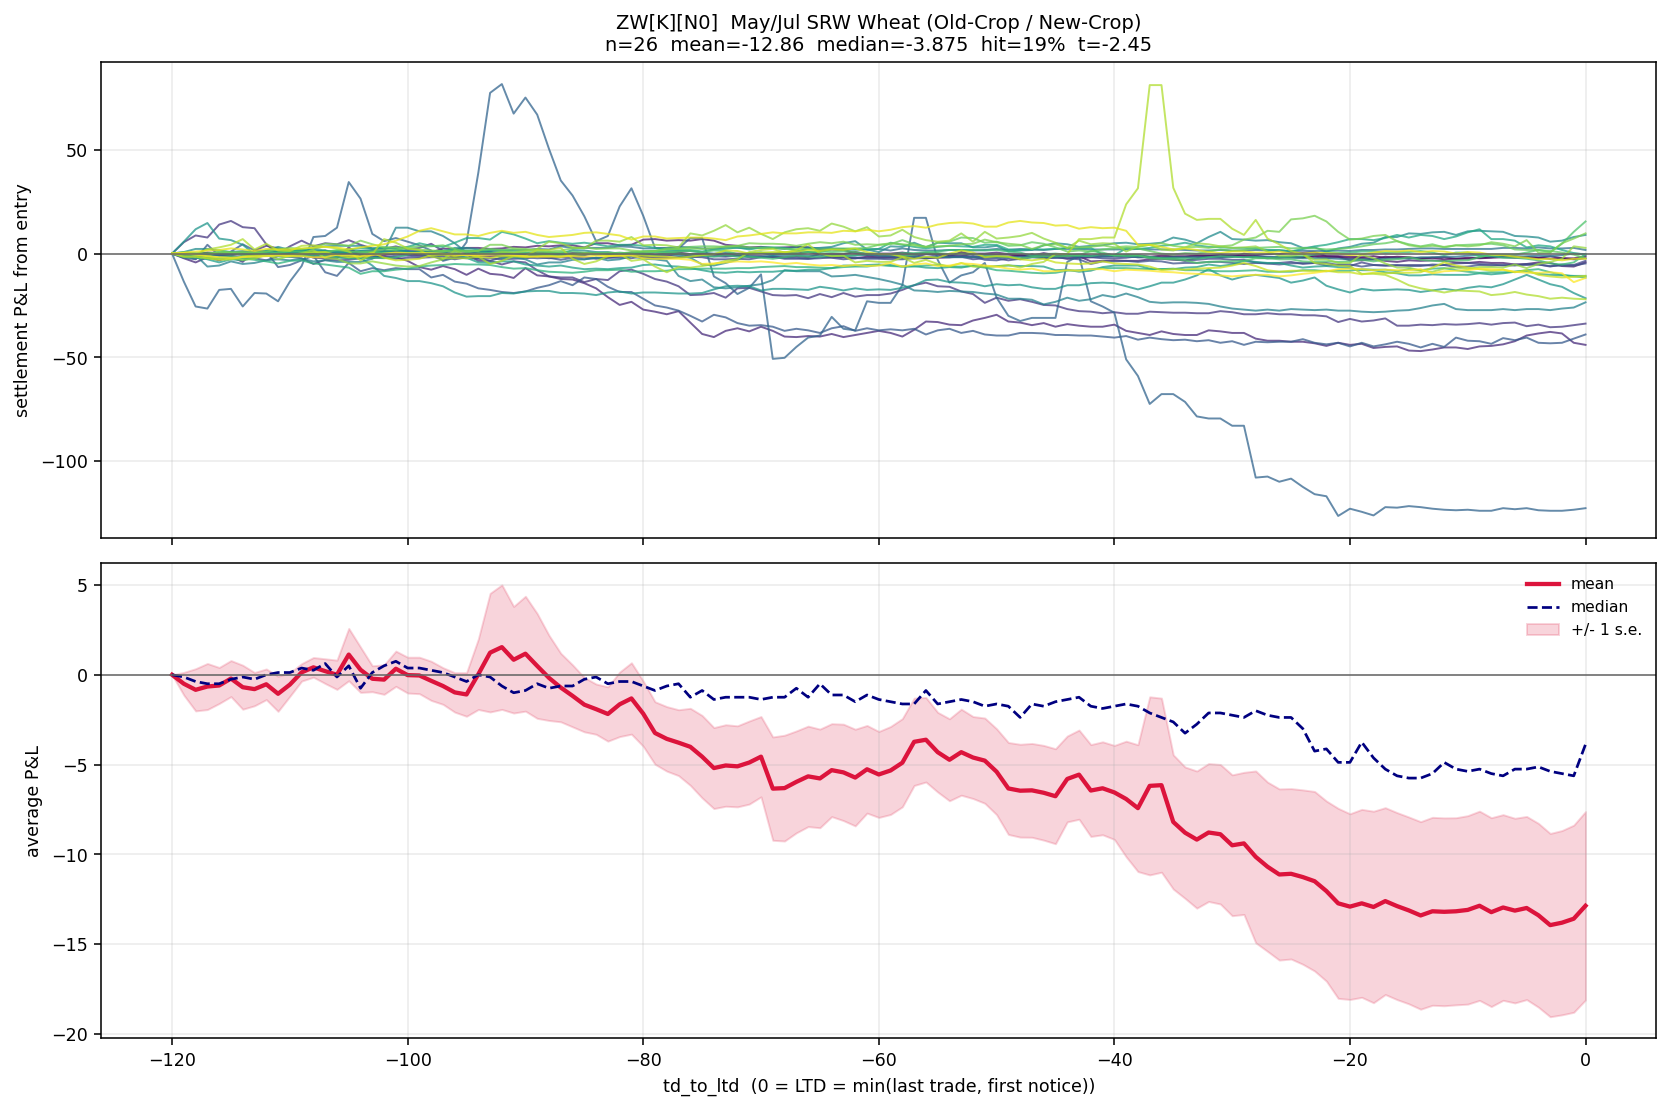

Strict full-window check passed: 26 instances x 121 offsets [-120, 0]
Instructor-package terminal-date source audit:


,ltd_source,fnd_is_rule,n_instances
0,last_bar,True,7
1,vendor,False,21


n=26, mean=-12.8558, median=-3.8750, positive_rate=19.2%, t=-2.45
Scenario agreement (negative full-window P&L): 21/26 = 80.8%

Positive (opposite-direction) years:
 instance   pnl
     2009  1.75
     2012  9.00
     2018 15.50
     2020  9.75
     2021  2.75

Condensed path at selected trading-day offsets:
              mean  median   n
td_to_ltd                     
-120        0.0000  0.0000  26
-60        -5.5481 -1.3750  26
-40        -6.5481 -1.7500  26
-20       -12.9038 -4.8750  26
-10       -13.0865 -5.3750  26
 0        -12.8558 -3.8750  26


In [26]:
df_zw = load_combo('ZW[K][N0]')
window_zw = (-120, 0)

fig, (cond_zw, wide_zw, per_zw, st_zw) = plot_combo(
    df_zw, window=window_zw,
    require_full=True, min_coverage=1.0,
    title='ZW[K][N0]  May/Jul SRW Wheat (Old-Crop / New-Crop)',
    outfile='zw_harvest.png',
)
plt.show()

assert_strict_full_window(wide_zw, window_zw)
expiry_audit_zw = print_expiry_source_audit(df_zw)
print_spread_diagnostics(cond_zw, per_zw, st_zw, expected_direction='down')


**(iii) Explanation:**

The May/July SRW wheat spread has the same old-crop/new-crop logic as corn, but the relevant pair occurs earlier because winter wheat is harvested earlier. **21 of 26 years (80.8%)** have a negative full-window P&L. The large gap between the mean (−12.86) and median (−3.88) indicates left skew: a few years with very large negative P&L pull the mean well below the typical outcome, so the t-statistic is partly driven by these tail observations. A downward mean path means the May old-crop premium is eroding relative to July as the new harvest approaches. The diagnostics above report the timing of the mean move and list every positive full-window exception directly from the data: **2009, 2012, 2018, 2020, and 2021**.

The exception years cluster into two recognizable groups. The **tight-supply cluster (2009, 2012, 2021)** shares a common thread of low U.S. wheat carry-in or carry-out stocks that supported old-crop values: **2009** occurred against a still-tight global wheat backdrop with low stocks and strong foreign demand; **2012** saw USDA lower 2011/12 carry-in estimates after stronger-than-expected food use and exports; **2021** began with lower carry-in stocks and a materially tighter balance sheet; USDA projected 2021/22 ending stocks down 11% and the season-average farm price at an eight-year high. The **domestic crop-stress cluster (2018, 2020)** reflects demand or supply shocks hitting the U.S. wheat market directly: **2018** coincided with substantial drought concern across the winter-wheat belt and a materially smaller projected crop; **2020** coincided with the COVID-era surge in U.S. retail flour and wheat-product demand documented by USDA. Taken together, these are reasonable fundamental settings in which May can retain more value relative to July than the normal seasonal pattern would imply.

**(iv) The t-statistic:** it tests a zero mean across the annual P&Ls under the standard one-sample assumptions. The finite annual sample, possible regime clustering/cross-year dependence, and commodity-return outliers limit precision. The statistic says nothing directly about transaction costs or whether the seasonal relationship will persist out of sample.

*Historical context sources: USDA ERS, Rising Wheat Prices Outpace Input Costs (2009); Wheat Outlook (June 2012, May 2018, May 2020, and May 2021).*

## (d) Lean hogs: cash settlement and convergence — HE[V][Z0]

**(i)** The spread is **`HE[V][Z0]`**: long one **October (V)** lean hogs, short one **December (Z)** of the same contract year. The long leg is October.


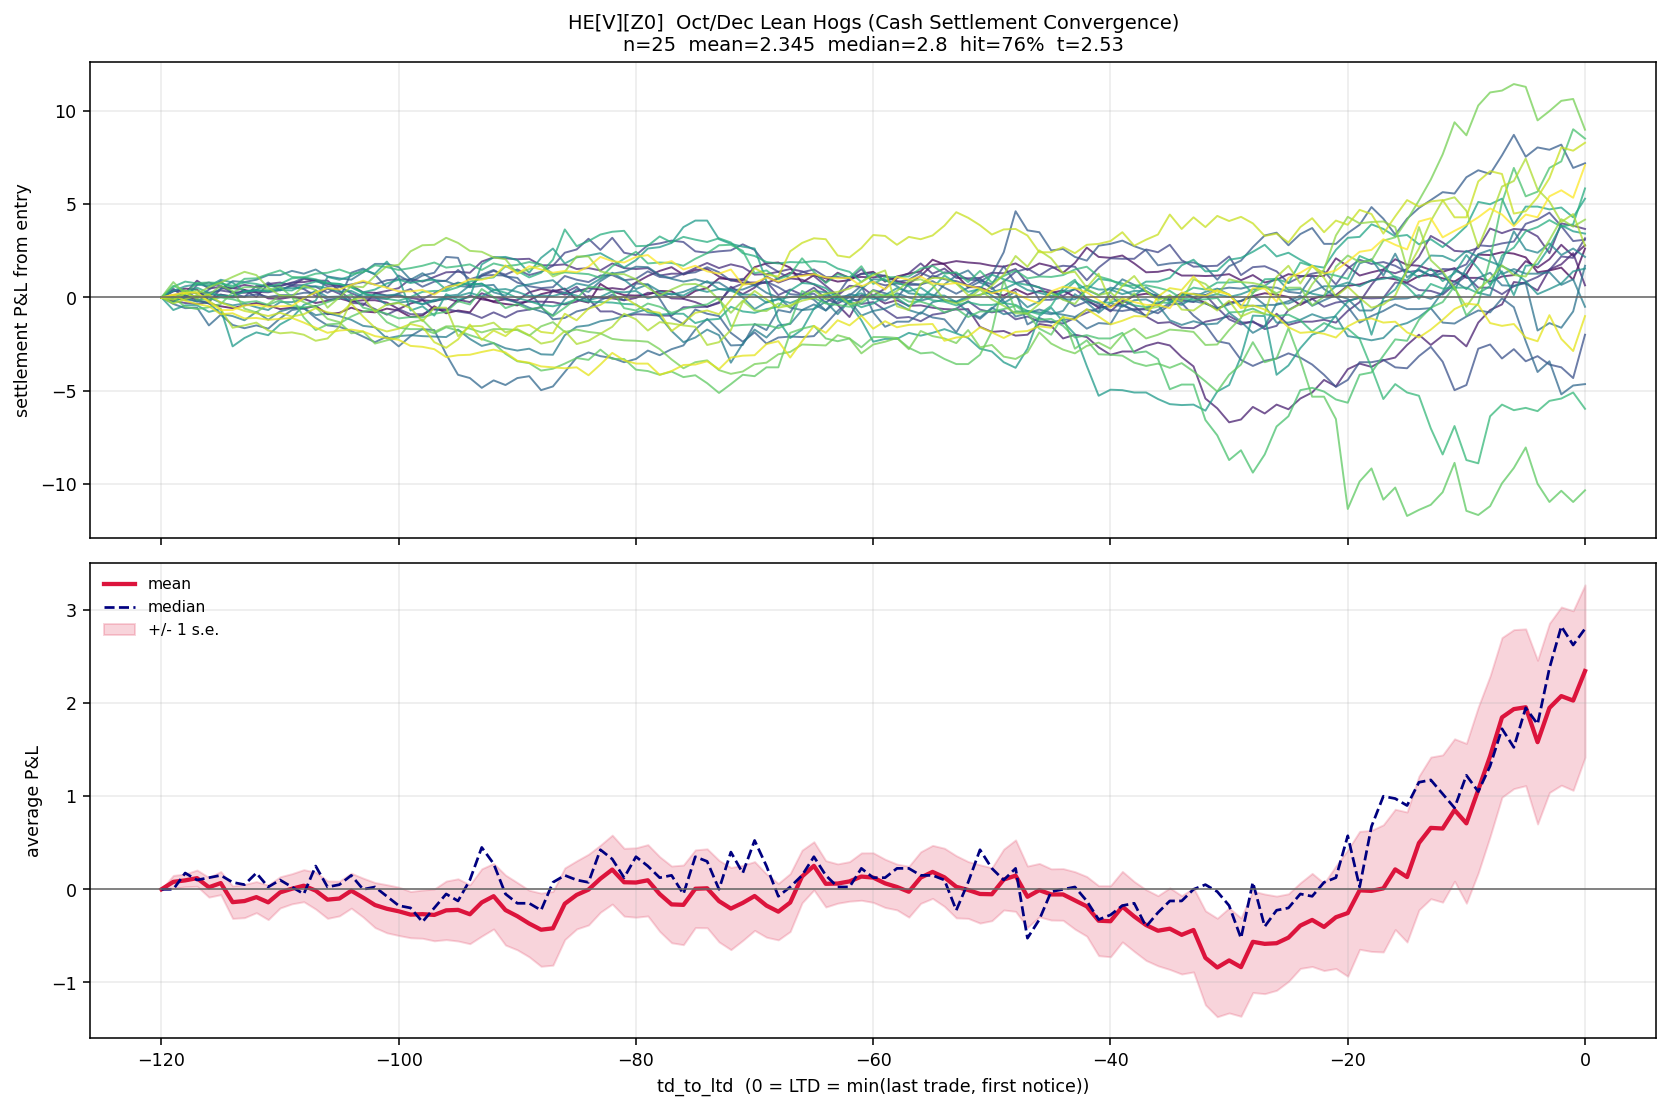

Strict full-window check passed: 25 instances x 121 offsets [-120, 0]
Instructor-package terminal-date source audit:


,ltd_source,fnd_is_rule,n_instances
0,last_bar,False,2
1,vendor,False,25


n=25, mean=2.3450, median=2.8000, positive_rate=76.0%, t=2.53
Scenario agreement (positive full-window P&L): 19/25 = 76.0%

Negative (opposite-direction) years:
 instance        pnl
     2007  -2.000000
     2009  -4.650009
     2011  -0.500000
     2017  -5.975006
     2019 -10.350006
     2024  -1.000000

Condensed path at selected trading-day offsets:
             mean  median   n
td_to_ltd                    
-120       0.0000  0.0000  25
-60        0.1260  0.1250  25
-40       -0.3430 -0.2750  25
-20       -0.2550  0.5750  25
-10        0.7090  1.2250  25
 0         2.3450  2.8000  25


In [27]:
df_he = load_combo('HE[V][Z0]')
window_he = (-120, 0)

fig, (cond_he, wide_he, per_he, st_he) = plot_combo(
    df_he, window=window_he,
    require_full=True, min_coverage=1.0,
    title='HE[V][Z0]  Oct/Dec Lean Hogs (Cash Settlement Convergence)',
    outfile='he_convergence.png',
)
plt.show()

assert_strict_full_window(wide_he, window_he)
expiry_audit_he = print_expiry_source_audit(df_he)
print_spread_diagnostics(cond_he, per_he, st_he, expected_direction='up')


**(iii) Explanation:**

The October/December lean-hog spread is different from the three physical-delivery examples. The long-run portion of the window is comparatively flat and the economically important mean move is concentrated near expiry; the -20, -10, and 0 diagnostics make that concentration explicit. **19 of 25 years (76.0%)** have a positive full-window P&L. The 76% agreement rate is the weakest of the four scenarios, and the t-statistic of 2.53 is modest relative to the stronger corn result. That is consistent with a pattern whose economically important move is concentrated in a relatively short convergence window and is therefore more exposed to year-specific variation. The average terminal direction is upward when October strengthens relative to December as the nearby cash-settled contract converges.

The negative exceptions are **2007, 2009, 2011, 2017, 2019, and 2024**. These years line up with several distinct departures from the usual nearby-convergence setup, but I treat the historical facts as context rather than causal identification. **2007** featured accelerating second-half pork production and USDA expectations for lower hog prices as slaughter supplies increased, a broad nearby-supply backdrop consistent with weaker front-contract support. **2009** was dominated by recession-related demand weakness and the H1N1 episode; USDA documented softer pork demand and export disruption, including China's ban on North American pork imports, conditions that plausibly weighed on nearby cash fundamentals. **2011** combined a sharp retreat in hog prices from their August record as larger fall hog numbers approached with unusually strong Asian export demand; that mix of immediate supply pressure and deferred demand support could disrupt the usual October/December convergence pattern. **2017** coincided with USDA projections for record U.S. pork production and higher slaughter numbers. **2019** coincided with rapidly rising expectations for Chinese pork imports after African swine fever sharply reduced China's hog supply, which plausibly strengthened deferred demand expectations. **2024** saw third-quarter pork production running about 4% above the prior year, helped by heavier hog weights, while July-August wholesale pork prices were about 9% lower year over year; that heavier near-term supply environment is consistent with an unusually weak October leg relative to December. None of these observations proves the cause of the individual spread move, but each supplies a contemporaneous fundamental mechanism consistent with the exception.

That overall behavior is consistent with the mechanism in the question: lean hog futures are cash-settled to the CME Lean Hog Index rather than through physical delivery, so the front contract's terminal convergence is concentrated late.

**(iv) The t-statistic:** as above, it is a proper one-sample test statistic for zero mean annual P&L under its assumptions. It does not convert the seasonal pattern into a causal result or an after-cost trading strategy. Here it is also important not to confuse a 120-session display window with 120 independent observations: the inferential sample is the set of annual instance P&Ls.

*Historical context sources: USDA ERS Livestock, Dairy, and Poultry Outlook (March 2007, September/November 2011, September 2024); USDA ERS China's Volatile Pork Industry (H1N1/2009); USDA livestock outlook for 2017; USDA FAS Pork 2019 Export Highlights.*

In [28]:
# Final reproducibility manifest.
# Question 1 direct WRDS pulls are frozen to the submitted dates above.
# Question 2 uses the instructor-supplied futspread package unchanged; for those
# derived combo files we record the actual date span produced by the run rather
# than claiming an unsupported package-level as-of cap.
repro_manifest = pd.DataFrame([
    {'artifact': 'COT raw query', 'snapshot_or_span': f'<= {COT_AS_OF_DATE:%Y-%m-%d}',
     'rows': len(cot_raw), 'first': cot_raw['date_'].min().date(),
     'last': cot_raw['date_'].max().date(), 'sha256': COT_SHA256},
    {'artifact': 'CL settlements (Q1)', 'snapshot_or_span': f'<= {CL_AS_OF_DATE:%Y-%m-%d}',
     'rows': len(cl_px), 'first': cl_px['date'].min().date(),
     'last': cl_px['date'].max().date(), 'sha256': CL_PRICE_SHA256},
    {'artifact': 'NG[H][J0] combo rows', 'snapshot_or_span': 'instructor futspread output',
     'rows': len(df_ng), 'first': df_ng['date'].min().date(),
     'last': df_ng['date'].max().date(), 'sha256': None},
    {'artifact': 'ZC[U][Z0] combo rows', 'snapshot_or_span': 'instructor futspread output',
     'rows': len(df_zc), 'first': df_zc['date'].min().date(),
     'last': df_zc['date'].max().date(), 'sha256': None},
    {'artifact': 'ZW[K][N0] combo rows', 'snapshot_or_span': 'instructor futspread output',
     'rows': len(df_zw), 'first': df_zw['date'].min().date(),
     'last': df_zw['date'].max().date(), 'sha256': None},
    {'artifact': 'HE[V][Z0] combo rows', 'snapshot_or_span': 'instructor futspread output',
     'rows': len(df_he), 'first': df_he['date'].min().date(),
     'last': df_he['date'].max().date(), 'sha256': None},
])
display(repro_manifest)
print('Python:', platform.python_version())
print('All assignment assertions completed.')


,artifact,snapshot_or_span,rows,first,last,sha256
0,COT raw query,<= 2026-09-08,44372,2006-06-06,2026-09-08,967457209b6c825bcc3de72c25375a52f20da679963b82...
1,CL settlements (Q1),<= 2026-04-03,487828,1999-11-22,2026-04-03,e1e6fe9e06b28c724596f375d9bbfe53eb4f91ccd3a485...
2,NG[H][J0] combo rows,instructor futspread output,13897,1998-02-25,2026-04-03,None
3,ZC[U][Z0] combo rows,instructor futspread output,12462,1999-05-21,2026-04-03,None
4,ZW[K][N0] combo rows,instructor futspread output,11718,1999-04-12,2026-04-03,None
5,HE[V][Z0] combo rows,instructor futspread output,8002,1999-09-15,2026-04-03,None


Python: 3.13.9
All assignment assertions completed.


---
*End of Assignment 2*
